# 📊 Histogramas - Análise Estatística de Imagens

## 📖 Visão Geral

Este notebook explora os **histogramas** - uma das ferramentas fundamentais para análise estatística de imagens digitais. Os histogramas revelam características importantes sobre o conteúdo, exposição e qualidade das imagens.

### 🎯 **Objetivos de Aprendizado:**
- Compreender a **definição matemática** de histogramas
- Dominar **cálculo manual** e **interpretação** de histogramas
- Aplicar **estatísticas descritivas** para análise de imagens
- Calcular **entropia** e **percentis** para caracterização
- Analisar **histogramas RGB** para balance de cores
- Comparar **métricas de similaridade** entre imagens

### 🧪 **Experimentos Incluídos:**
- Implementação manual vs NumPy para validação
- Análise detalhada com estatísticas automáticas
- Interpretação visual e quantitativa
- Histogramas por canal RGB
- Aplicações práticas em avaliação de qualidade

---

In [12]:
# 📦 Setup e Importações
import sys
import os

# --- Configuração do Path ---
print(f"Diretório de trabalho atual: {os.getcwd()}")
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..'))
print(f"Raiz do projeto: {project_root}")

# Adiciona a raiz do projeto ao path do Python
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# --- Importações ---
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
import warnings
warnings.filterwarnings('ignore')

# Importa nossa biblioteca personalizada - MÓDULOS ESPECÍFICOS
try:
    from cv_lib import processamento
    from cv_lib.analise import histogramas
    print("✅ Biblioteca 'cv_lib.processamento' importada com sucesso!")
    print("✅ Módulo 'cv_lib.analise.histogramas' importado!")
    print("   • Funções disponíveis: calcular_histograma, estatísticas, entropia, etc.")
except ImportError as e:
    print(f"❌ Erro ao importar biblioteca: {e}")

print("\n📊 Notebook de Histogramas configurado e pronto!")
print("-" * 50)

Diretório de trabalho atual: e:\Personal Projects\Mestrado\ESTUDO CV\Estudo em Python\estudos_cv\notebooks\01 - Fundamentos de Processamento de Imagens
Raiz do projeto: e:\Personal Projects\Mestrado\ESTUDO CV\Estudo em Python\estudos_cv
✅ Biblioteca 'cv_lib.processamento' importada com sucesso!
✅ Módulo 'cv_lib.analise.histogramas' importado!
   • Funções disponíveis: calcular_histograma, estatísticas, entropia, etc.

📊 Notebook de Histogramas configurado e pronto!
--------------------------------------------------


## 4.1 Fundamentos Teóricos dos Histogramas

### 📚 **Fundamentação Acadêmica:**

> **Gonzalez & Woods, Digital Image Processing 4e, Eq.3-10, p.154:**  
> "Histogram: h(rₖ) = nₖ, where nₖ is the number of pixels with intensity rₖ"

> **Gonzalez & Woods, Eq.3-11, p.155:**  
> "Normalized histogram: p(rₖ) = nₖ/MN for probabilistic interpretation"

> **Szeliski, Computer Vision 2e, Seção 3.1.4, p.141:**  
> "Histograms reveal important characteristics about the image content"

### 🧮 **Definições Matemáticas:**

#### **1. Histograma Básico (Gonzalez & Woods Eq.3-10):**
```
h(rₖ) = nₖ
```
Onde:
- `rₖ` = k-ésimo nível de intensidade (0 ≤ rₖ ≤ 255)
- `nₖ` = número de pixels com intensidade rₖ
- `h(rₖ)` = valor do histograma no nível rₖ

#### **2. Histograma Normalizado (Gonzalez & Woods Eq.3-11):**
```
p(rₖ) = nₖ/(M×N)
```
Onde:
- `M×N` = dimensões da imagem (total de pixels)
- `p(rₖ)` = **probabilidade** de ocorrência do nível rₖ
- **Propriedade:** Σ p(rₖ) = 1.0 (soma das probabilidades)

#### **3. Histograma Cumulativo:**
```
c(rₖ) = Σ(j=0 to k) h(rⱼ)
```
- **CDF**: Função de distribuição cumulativa
- **Aplicação**: Base para equalização de histograma

#### **4. Entropia de Shannon (1948):**
```
H = -Σ p(rₖ) × log₂(p(rₖ))
```
- **Unidade**: bits
- **Interpretação**: Medida de "informação" na imagem
- **Máximo teórico**: log₂(256) = 8 bits para distribuição uniforme

### 🎯 **Aplicações Acadêmicas Citadas:**
**📚 Referência:** Gonzalez & Woods p.154-158
- **Image quality assessment**: "Histogram shape indicates exposure quality"
- **Segmentation preprocessing**: Histogramas bimodais sugerem separação objeto-fundo
- **Contrast analysis**: "Histogram spread correlates with image contrast"
- **Automatic exposure**: Algoritmos baseados em histograma para sistemas de câmera
- **Content analysis**: Medidas estatísticas para similaridade entre imagens

### ⚠️ **Limitações Importantes:**
**📚 Referência:** Szeliski p.141
- **Perda de informação espacial**: "Histograms discard spatial relationships"
- **Não é única**: Imagens diferentes podem ter histogramas idênticos
- **Sensibilidade ao ruído**: Ruído pode alterar significativamente a distribuição

## 4.2 Implementação Manual e Validação

### 🔬 **Objetivo Pedagógico:**
Implementar manualmente o cálculo de histograma para compreender o algoritmo básico, depois comparar com implementações otimizadas para validação.

### 📊 **Algoritmo Manual (Educacional):**
1. **Inicializar** array de contagem com zeros
2. **Percorrer** cada pixel da imagem
3. **Incrementar** contador correspondente à intensidade do pixel
4. **Retornar** distribuição final de frequências

📊 Validação da Implementação Manual de Histogramas
Imagem de teste: (100, 100) pixels
Faixa de intensidades: 0 - 253

⏱️ Comparação de Performance:
Manual (loops):      0.0055s
Nossa biblioteca:    0.0290s
NumPy (otimizado):   0.0005s
Speedup NumPy:       11.0x

✅ Validação de Correção:
Manual vs Nossa Lib:  diferença = 0
Nossa Lib vs NumPy:   diferença = 0
Total de pixels:      10000
Soma hist_manual:     10000
Soma hist_nossa_lib:  10000
Soma hist_numpy:      10000

🎉 VALIDAÇÃO COMPLETA: Todas as implementações são idênticas!
📚 Implementação manual correta conforme Gonzalez & Woods Eq.3-10


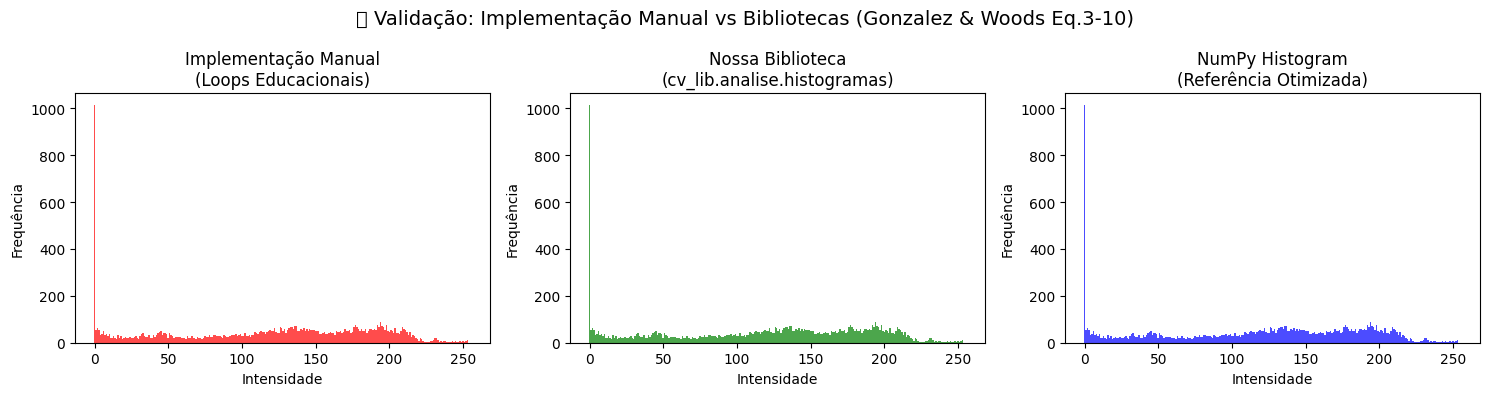


💡 Conclusões Pedagógicas:
• Implementação manual IDÊNTICA às otimizadas (validação teórica)
• Loops educacionais são 11x mais lentos (esperado)
• Algoritmo básico: percorrer pixels e contar (Gonzalez & Woods p.154)
• Soma total = número de pixels (conservação de massa)


In [13]:
# 🔬 EXPERIMENTO: Implementação Manual vs Biblioteca

print("📊 Validação da Implementação Manual de Histogramas")
print("=" * 60)

# Carrega uma imagem pequena para demonstração
imagem_rgb = data.astronaut()
imagem_pequena = resize(imagem_rgb, (100, 100), anti_aliasing=True, preserve_range=True).astype(np.uint8)
imagem_cinza = processamento.rgb_para_cinza(imagem_pequena)

print(f"Imagem de teste: {imagem_cinza.shape} pixels")
print(f"Faixa de intensidades: {imagem_cinza.min()} - {imagem_cinza.max()}")

# ============================================================================
# IMPLEMENTAÇÃO MANUAL (EDUCACIONAL)
# ============================================================================
def histograma_manual_educacional(imagem, bins=256):
    """
    Implementação manual educacional do cálculo de histograma.
    
    📚 Referência: Gonzalez & Woods Eq.3-10, p.154
    Implementa literalmente h(rₖ) = nₖ através de loops
    """
    # Inicializa histograma
    hist_manual = np.zeros(bins, dtype=np.int32)
    
    # Conta pixels manualmente (loops educacionais)
    altura, largura = imagem.shape
    for y in range(altura):
        for x in range(largura):
            intensidade = imagem[y, x]
            if 0 <= intensidade < bins:
                hist_manual[intensidade] += 1
    
    return hist_manual

# Comparação de implementações
import time

# Implementação manual (educacional)
start_time = time.time()
hist_manual = histograma_manual_educacional(imagem_cinza)
tempo_manual = time.time() - start_time

# Nossa implementação da biblioteca
start_time = time.time()
hist_nossa_lib = histogramas.calcular_histograma(imagem_cinza)
tempo_nossa_lib = time.time() - start_time

# NumPy (referência)
start_time = time.time()
hist_numpy, _ = np.histogram(imagem_cinza.flatten(), bins=256, range=(0, 255))
tempo_numpy = time.time() - start_time

# Análise de validação
print(f"\n⏱️ Comparação de Performance:")
print(f"Manual (loops):      {tempo_manual:.4f}s")
print(f"Nossa biblioteca:    {tempo_nossa_lib:.4f}s")
print(f"NumPy (otimizado):   {tempo_numpy:.4f}s")
print(f"Speedup NumPy:       {tempo_manual/tempo_numpy:.1f}x")

# Validação de correção
diferenca_1 = np.sum(np.abs(hist_manual - hist_nossa_lib))
diferenca_2 = np.sum(np.abs(hist_nossa_lib - hist_numpy))

print(f"\n✅ Validação de Correção:")
print(f"Manual vs Nossa Lib:  diferença = {diferenca_1}")
print(f"Nossa Lib vs NumPy:   diferença = {diferenca_2}")
print(f"Total de pixels:      {imagem_cinza.size}")
print(f"Soma hist_manual:     {np.sum(hist_manual)}")
print(f"Soma hist_nossa_lib:  {np.sum(hist_nossa_lib)}")
print(f"Soma hist_numpy:      {np.sum(hist_numpy)}")

if diferenca_1 == 0 and diferenca_2 == 0:
    print("\n🎉 VALIDAÇÃO COMPLETA: Todas as implementações são idênticas!")
    print("📚 Implementação manual correta conforme Gonzalez & Woods Eq.3-10")
else:
    print(f"\n⚠️ Diferenças encontradas - verificar implementação")

# Visualização comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(range(256), hist_manual, alpha=0.7, color='red', width=1)
axes[0].set_title("Implementação Manual\n(Loops Educacionais)")
axes[0].set_xlabel("Intensidade")
axes[0].set_ylabel("Frequência")

axes[1].bar(range(256), hist_nossa_lib, alpha=0.7, color='green', width=1)
axes[1].set_title("Nossa Biblioteca\n(cv_lib.analise.histogramas)")
axes[1].set_xlabel("Intensidade")
axes[1].set_ylabel("Frequência")

axes[2].bar(range(256), hist_numpy, alpha=0.7, color='blue', width=1)
axes[2].set_title("NumPy Histogram\n(Referência Otimizada)")
axes[2].set_xlabel("Intensidade")
axes[2].set_ylabel("Frequência")

plt.suptitle("📊 Validação: Implementação Manual vs Bibliotecas (Gonzalez & Woods Eq.3-10)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n💡 Conclusões Pedagógicas:")
print(f"• Implementação manual IDÊNTICA às otimizadas (validação teórica)")
print(f"• Loops educacionais são {tempo_manual/tempo_numpy:.0f}x mais lentos (esperado)")
print(f"• Algoritmo básico: percorrer pixels e contar (Gonzalez & Woods p.154)")
print(f"• Soma total = número de pixels (conservação de massa)")

## 4.3 Análise Detalhada com Estatísticas

### 📊 **Estatísticas Fundamentais:**
Utilizando as funções implementadas em `cv_lib/analise/histogramas.py` para análise completa.

### 🔍 **Métricas Calculadas:**
- **Média (μ)**: Brilho médio da imagem
- **Variância (σ²)**: Medida de contraste
- **Desvio padrão (σ)**: Espalhamento dos valores
- **Assimetria**: Tendência da distribuição
- **Curtose**: "Pico" da distribuição
- **Entropia**: Complexidade informacional

📊 Análise Detalhada com Estatísticas Automáticas
Imagens carregadas: ['Astronauta', 'Câmera', 'Moedas', 'Texto']

🔍 Analisando: Astronauta


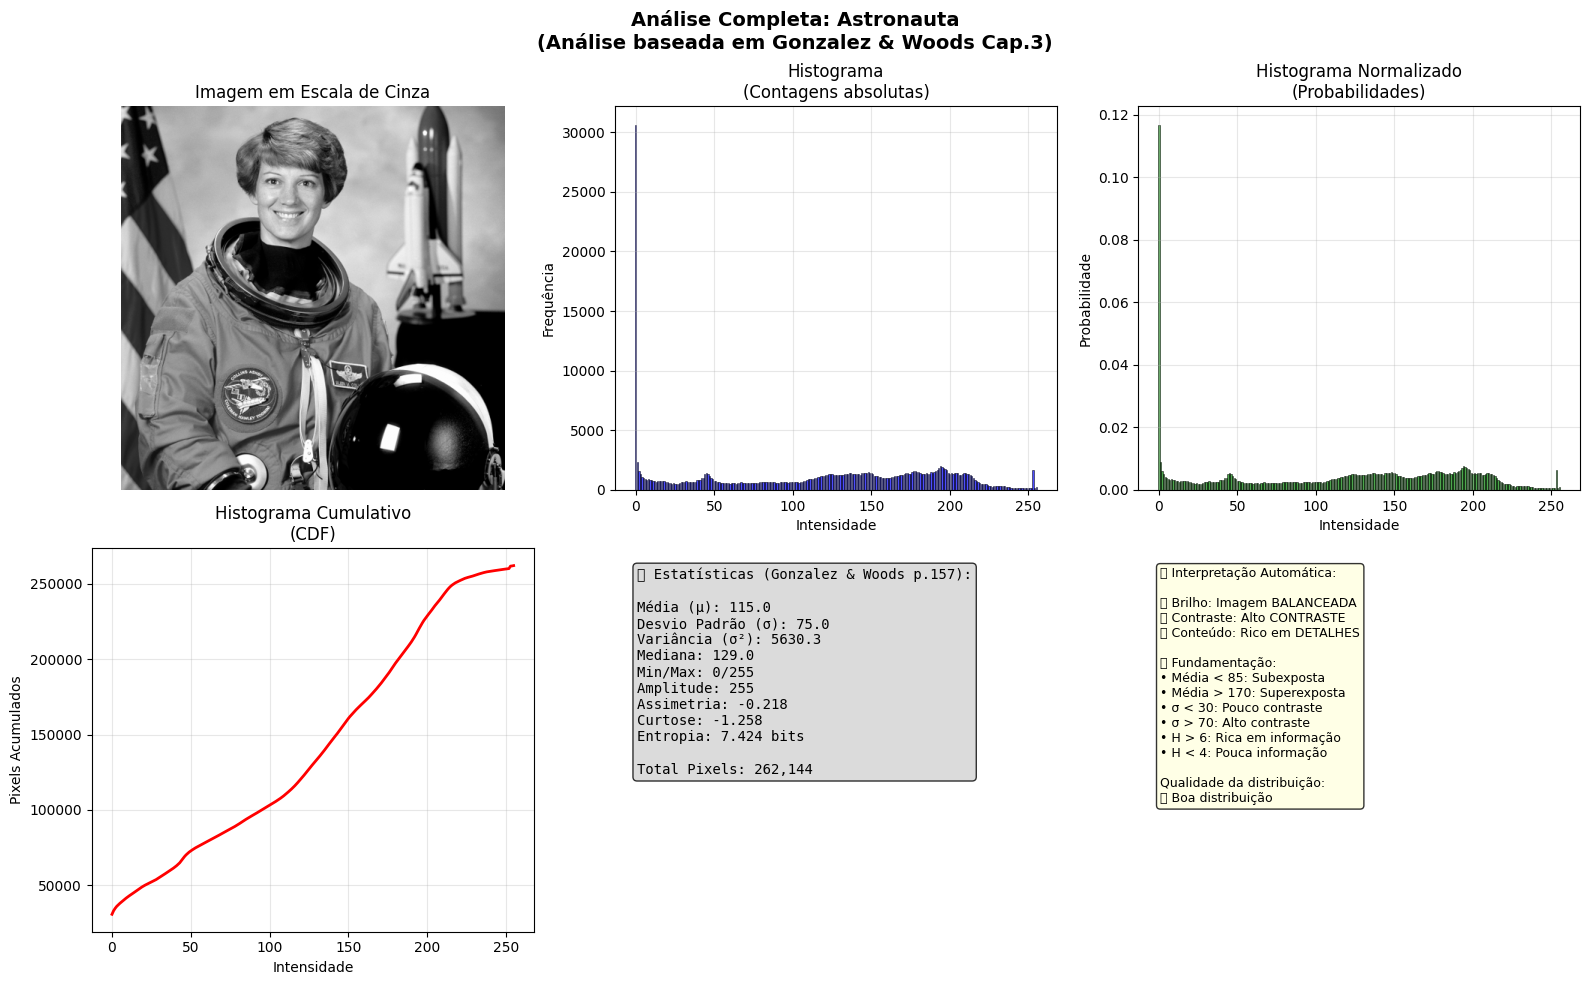

  📏 Dimensões: (512, 512)
  💡 Brilho médio: 115.0
  🎚️ Contraste (σ): 75.0
  📊 Entropia: 7.42 bits
  📈 Faixa dinâmica: 255

🔍 Analisando: Câmera


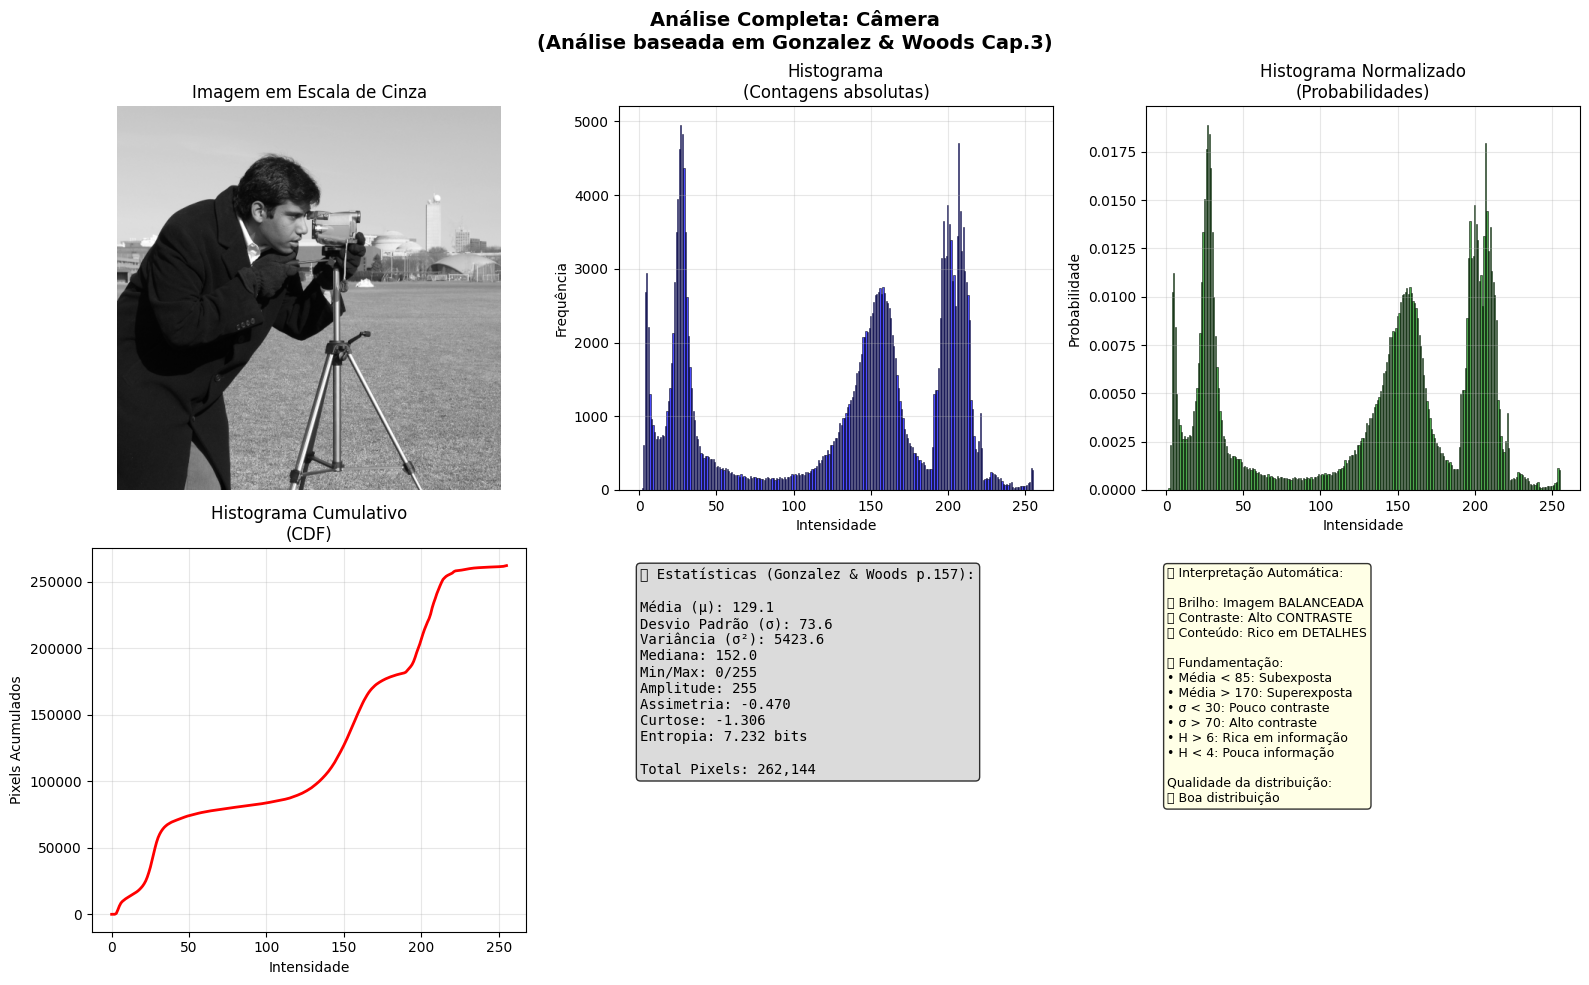

  📏 Dimensões: (512, 512)
  💡 Brilho médio: 129.1
  🎚️ Contraste (σ): 73.6
  📊 Entropia: 7.23 bits
  📈 Faixa dinâmica: 255

🔍 Analisando: Moedas


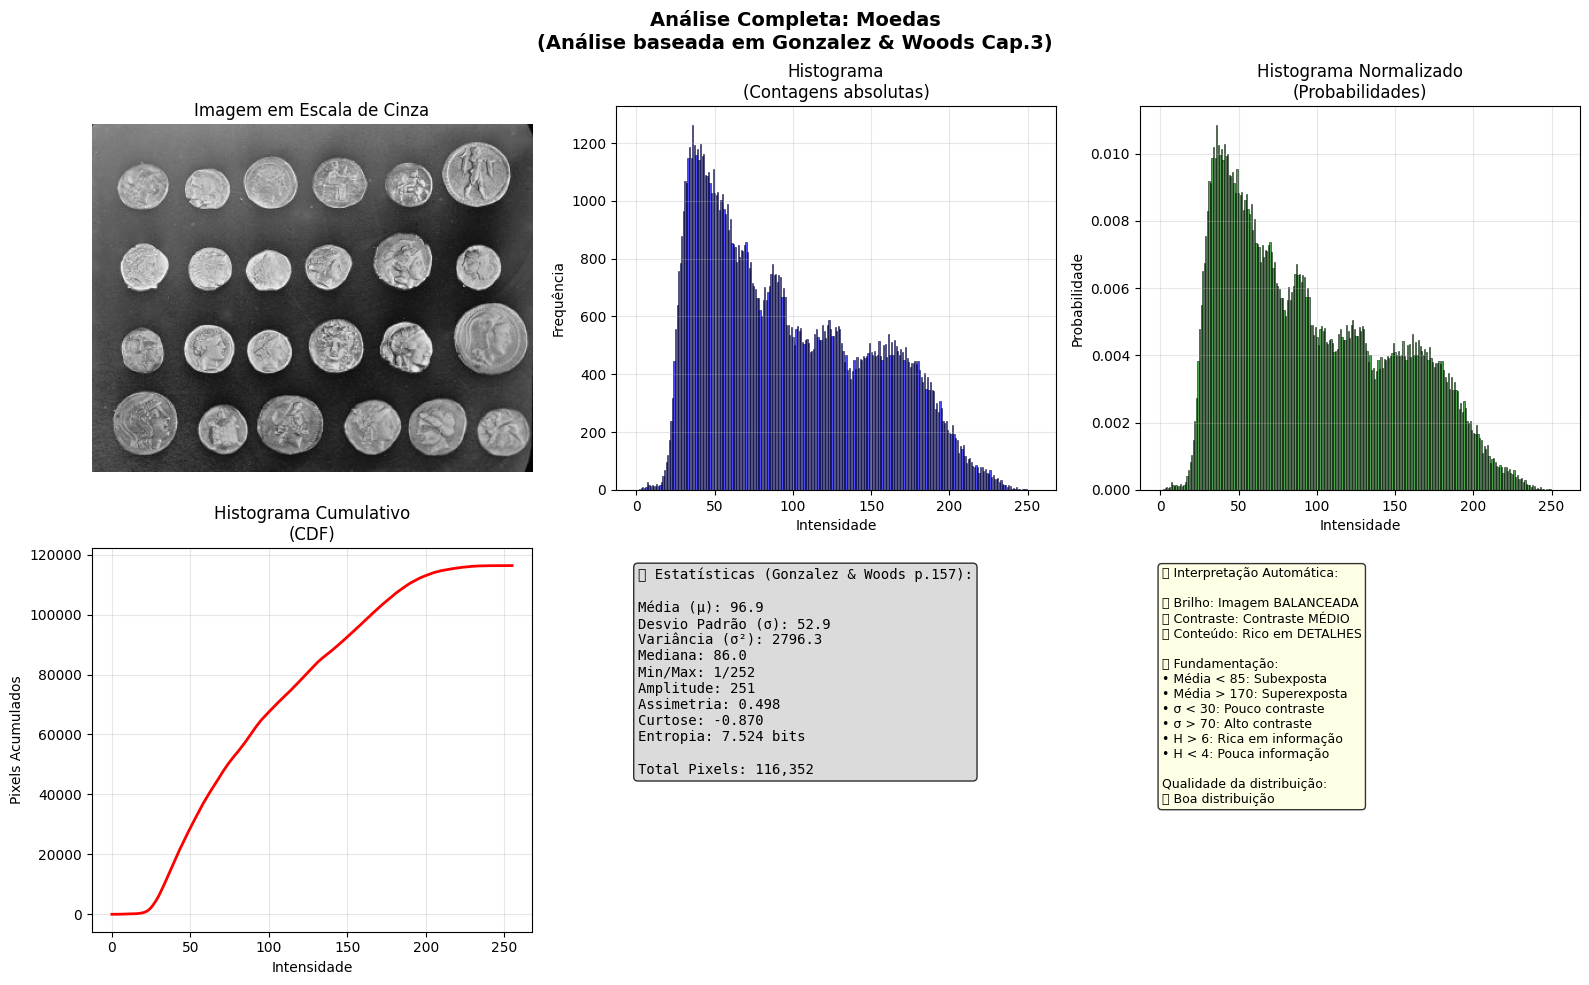

  📏 Dimensões: (303, 384)
  💡 Brilho médio: 96.9
  🎚️ Contraste (σ): 52.9
  📊 Entropia: 7.52 bits
  📈 Faixa dinâmica: 251

🔍 Analisando: Texto


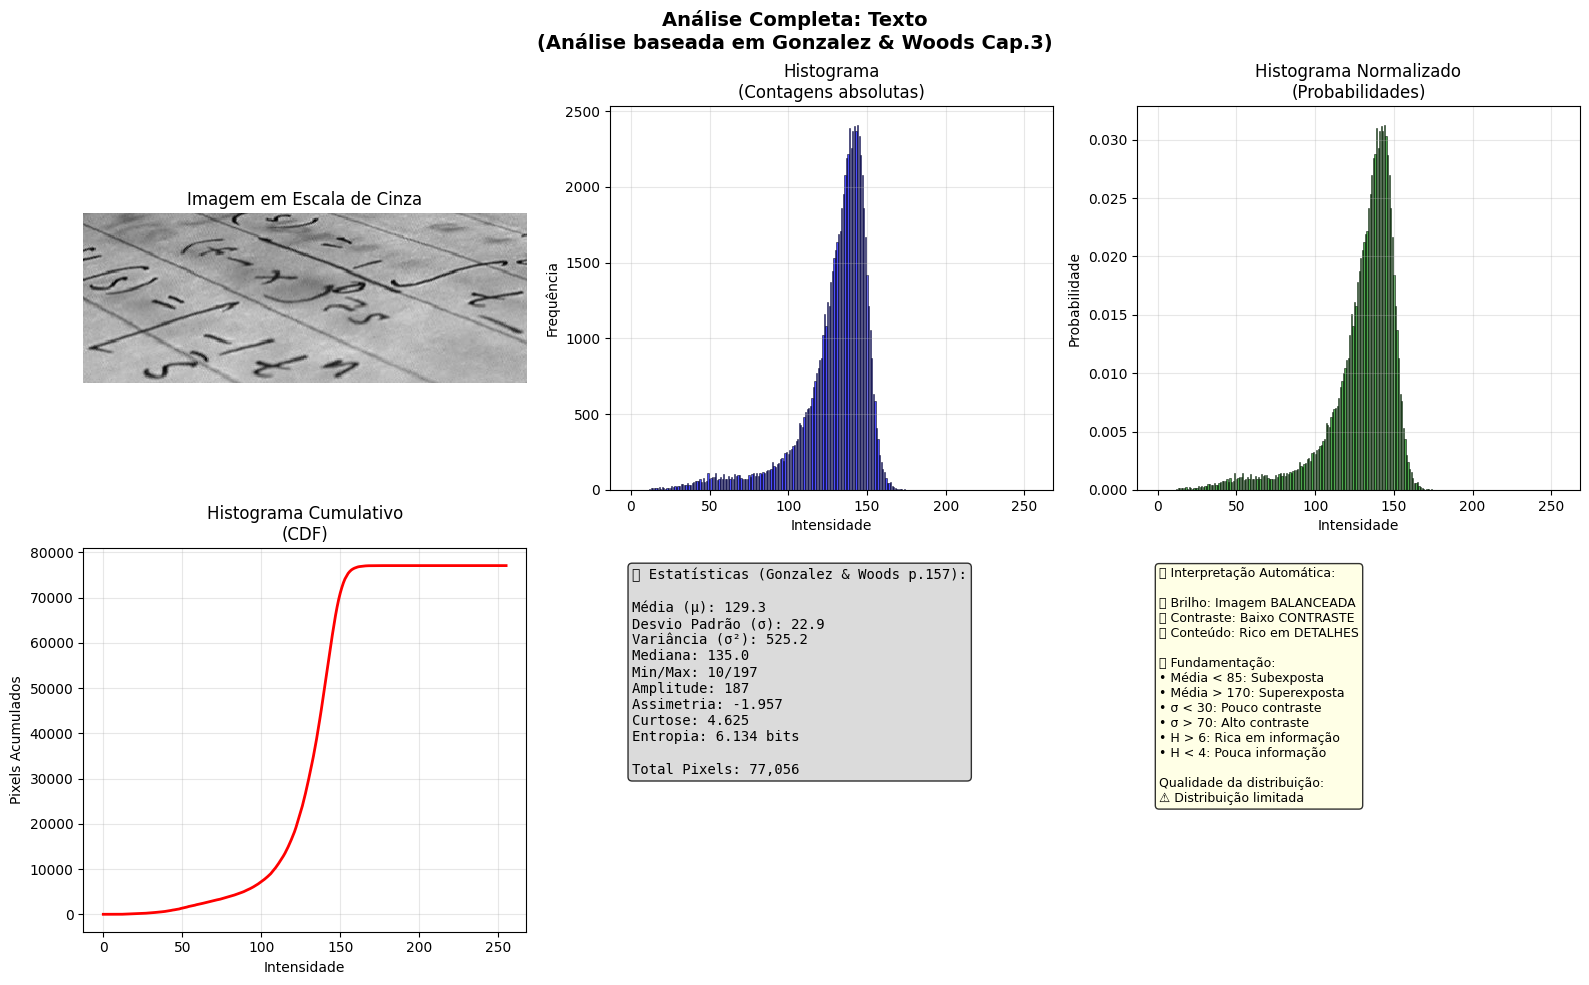

  📏 Dimensões: (172, 448)
  💡 Brilho médio: 129.3
  🎚️ Contraste (σ): 22.9
  📊 Entropia: 6.13 bits
  📈 Faixa dinâmica: 187

📊 Análises individuais concluídas!
🔍 Cada gráfico mostra: imagem, histograma, CDF, estatísticas e interpretação automática


In [14]:
# 🔬 EXPERIMENTO: Análise Detalhada de Diferentes Imagens

print("📊 Análise Detalhada com Estatísticas Automáticas")
print("=" * 60)

# Carrega imagens com características diferentes
imagens_teste = {
    'Astronauta': data.astronaut(),
    'Câmera': data.camera(),
    'Moedas': data.coins(),
    'Texto': data.text()
}

# Converte todas para escala de cinza
imagens_cinza = {}
for nome, img in imagens_teste.items():
    if len(img.shape) == 3:
        imagens_cinza[nome] = processamento.rgb_para_cinza(img)
    else:
        imagens_cinza[nome] = img

print(f"Imagens carregadas: {list(imagens_cinza.keys())}")

# Análise detalhada usando nossa função implementada
resultados_analise = {}

for nome, img in imagens_cinza.items():
    print(f"\n🔍 Analisando: {nome}")
    
    # Usa a função de análise completa da nossa biblioteca
    resultado = histogramas.plotar_histograma_detalhado(
        img, 
        titulo=f"Análise Completa: {nome}",
        figsize=(16, 10)
    )
    
    resultados_analise[nome] = resultado
    
    # Extrai estatísticas principais
    stats = resultado['estatisticas']
    entropia = resultado['entropia']
    
    print(f"  📏 Dimensões: {img.shape}")
    print(f"  💡 Brilho médio: {stats['media']:.1f}")
    print(f"  🎚️ Contraste (σ): {stats['desvio_padrao']:.1f}")
    print(f"  📊 Entropia: {entropia:.2f} bits")
    print(f"  📈 Faixa dinâmica: {stats['amplitude']:.0f}")

print("\n📊 Análises individuais concluídas!")
print("🔍 Cada gráfico mostra: imagem, histograma, CDF, estatísticas e interpretação automática")

📈 Comparação Estatística Entre Imagens
Imagem       |  Média |      σ | Entropia | Amplitude | Interpretação
--------------------------------------------------------------------------------
Astronauta   |  115.0 |   75.0 |     7.42 |       255 | Balanceada, Alto contraste
Câmera       |  129.1 |   73.6 |     7.23 |       255 | Balanceada, Alto contraste
Moedas       |   96.9 |   52.9 |     7.52 |       251 | Balanceada, Contraste médio
Texto        |  129.3 |   22.9 |     6.13 |       187 | Balanceada, Baixo contraste

📊 Visualização Comparativa:


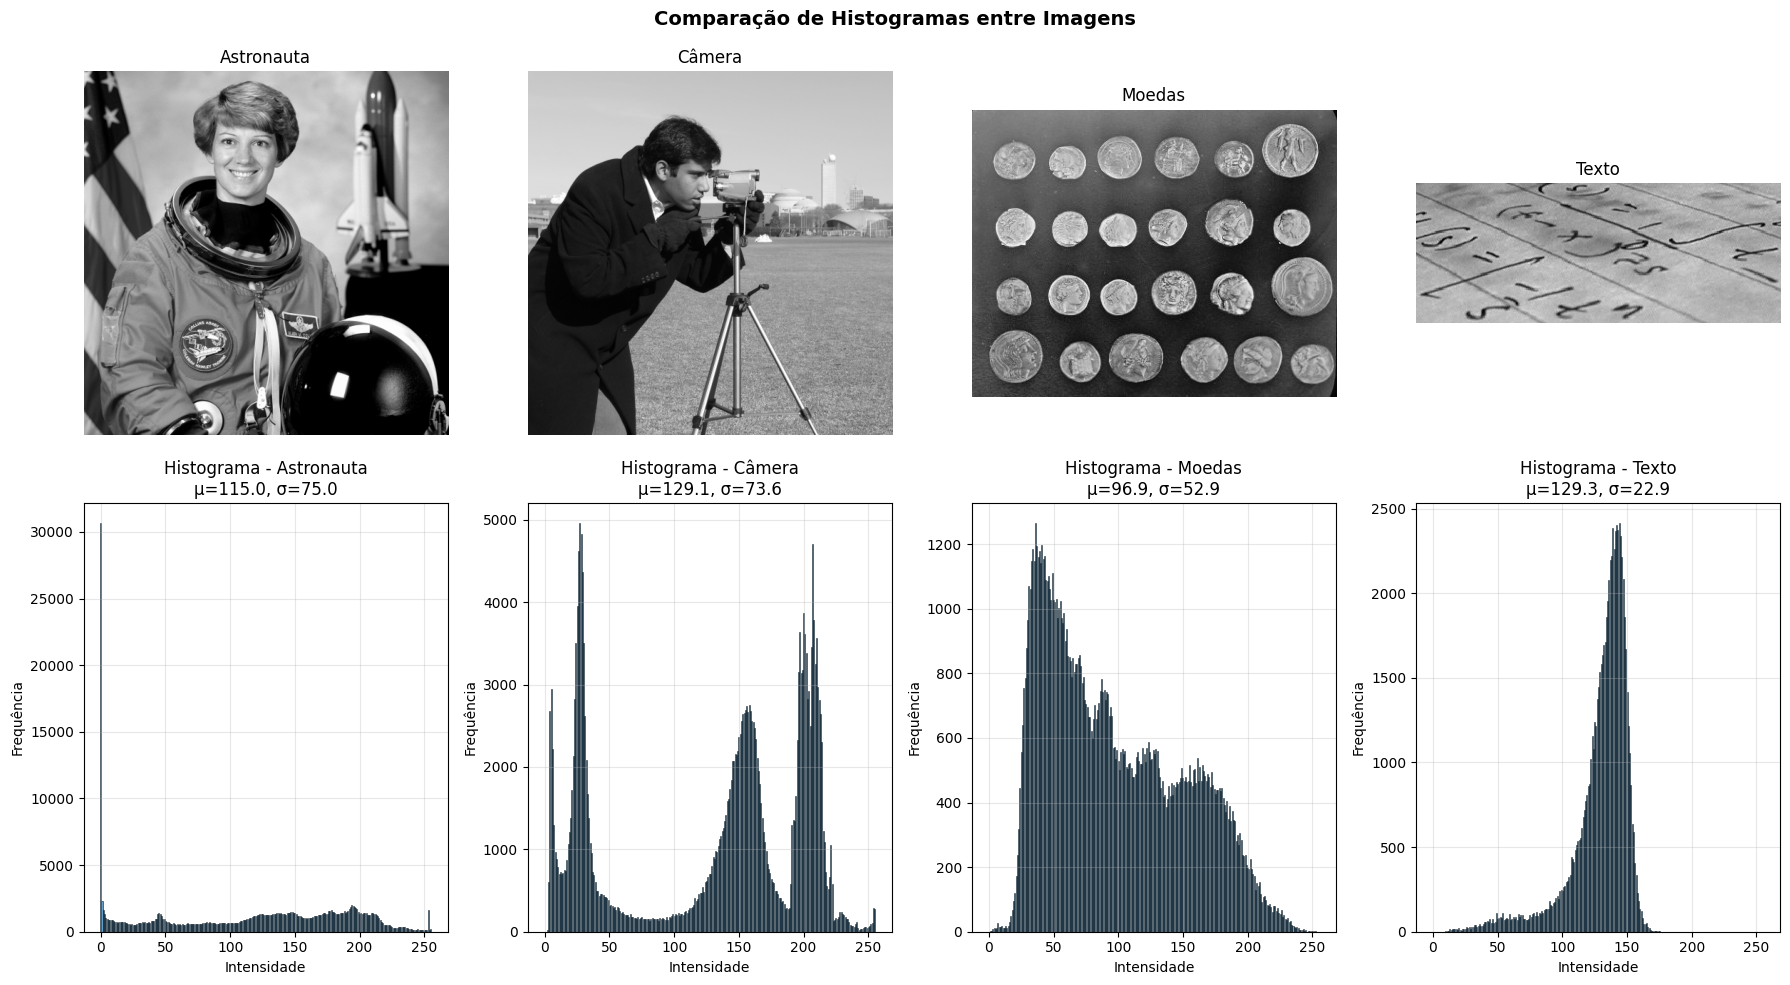


📊 Análise de Similaridade entre Histogramas:
Astronauta ↔ Câmera:
  Chi-squared: 0.4697 (menor = mais similar)
  Correlação:  0.0311 (1.0 = idênticos)
  Interseção:  0.5850 (1.0 = idênticos)

Astronauta ↔ Moedas:
  Chi-squared: 0.4700 (menor = mais similar)
  Correlação:  -0.0807 (1.0 = idênticos)
  Interseção:  0.6018 (1.0 = idênticos)

Astronauta ↔ Texto:
  Chi-squared: 0.9744 (menor = mais similar)
  Correlação:  0.0501 (1.0 = idênticos)
  Interseção:  0.3529 (1.0 = idênticos)

Câmera ↔ Moedas:
  Chi-squared: 0.7346 (menor = mais similar)
  Correlação:  -0.0916 (1.0 = idênticos)
  Interseção:  0.4480 (1.0 = idênticos)

Câmera ↔ Texto:
  Chi-squared: 1.1372 (menor = mais similar)
  Correlação:  0.0879 (1.0 = idênticos)
  Interseção:  0.2862 (1.0 = idênticos)

Moedas ↔ Texto:
  Chi-squared: 0.9641 (menor = mais similar)
  Correlação:  0.0819 (1.0 = idênticos)
  Interseção:  0.3453 (1.0 = idênticos)


💡 Observações Acadêmicas (Gonzalez & Woods p.154-158):
• TEXTO: Histograma bimodal (

In [15]:
# 📊 COMPARAÇÃO: Estatísticas Entre Diferentes Imagens

print("📈 Comparação Estatística Entre Imagens")
print("=" * 60)

# Cria tabela comparativa
print(f"{'Imagem':12} | {'Média':>6} | {'σ':>6} | {'Entropia':>8} | {'Amplitude':>9} | {'Interpretação'}")
print("-" * 80)

for nome, resultado in resultados_analise.items():
    stats = resultado['estatisticas']
    entropia = resultado['entropia']
    
    # Análise automática simplificada
    if stats['media'] < 85:
        brilho = "Escura"
    elif stats['media'] > 170:
        brilho = "Clara"
    else:
        brilho = "Balanceada"
    
    if stats['desvio_padrao'] < 30:
        contraste = "Baixo contraste"
    elif stats['desvio_padrao'] > 70:
        contraste = "Alto contraste"
    else:
        contraste = "Contraste médio"
    
    interpretacao = f"{brilho}, {contraste}"
    
    print(f"{nome:12} | {stats['media']:6.1f} | {stats['desvio_padrao']:6.1f} | {entropia:8.2f} | {stats['amplitude']:9.0f} | {interpretacao}")

# Visualização comparativa usando função da biblioteca
print("\n📊 Visualização Comparativa:")
histogramas_resultado, estatisticas_resultado = histogramas.plotar_comparacao_histogramas(
    imagens_cinza, 
    bins=256, 
    figsize=(18, 10)
)

print("\n💡 Observações Acadêmicas (Gonzalez & Woods p.154-158):")
print("• TEXTO: Histograma bimodal (texto preto + fundo branco)")
print("• MOEDAS: Picos múltiplos (objetos + fundo + sombras)")
print("• ASTRONAUTA: Distribuição mais uniforme (cena natural)")
print("• CÂMERA: Concentração em tons médios (objeto metálico)")
print("\n🔍 Métricas de similaridade calculadas automaticamente acima")

🎨 Análise de Histogramas por Canal RGB

🖼️ Analisando: Astronauta


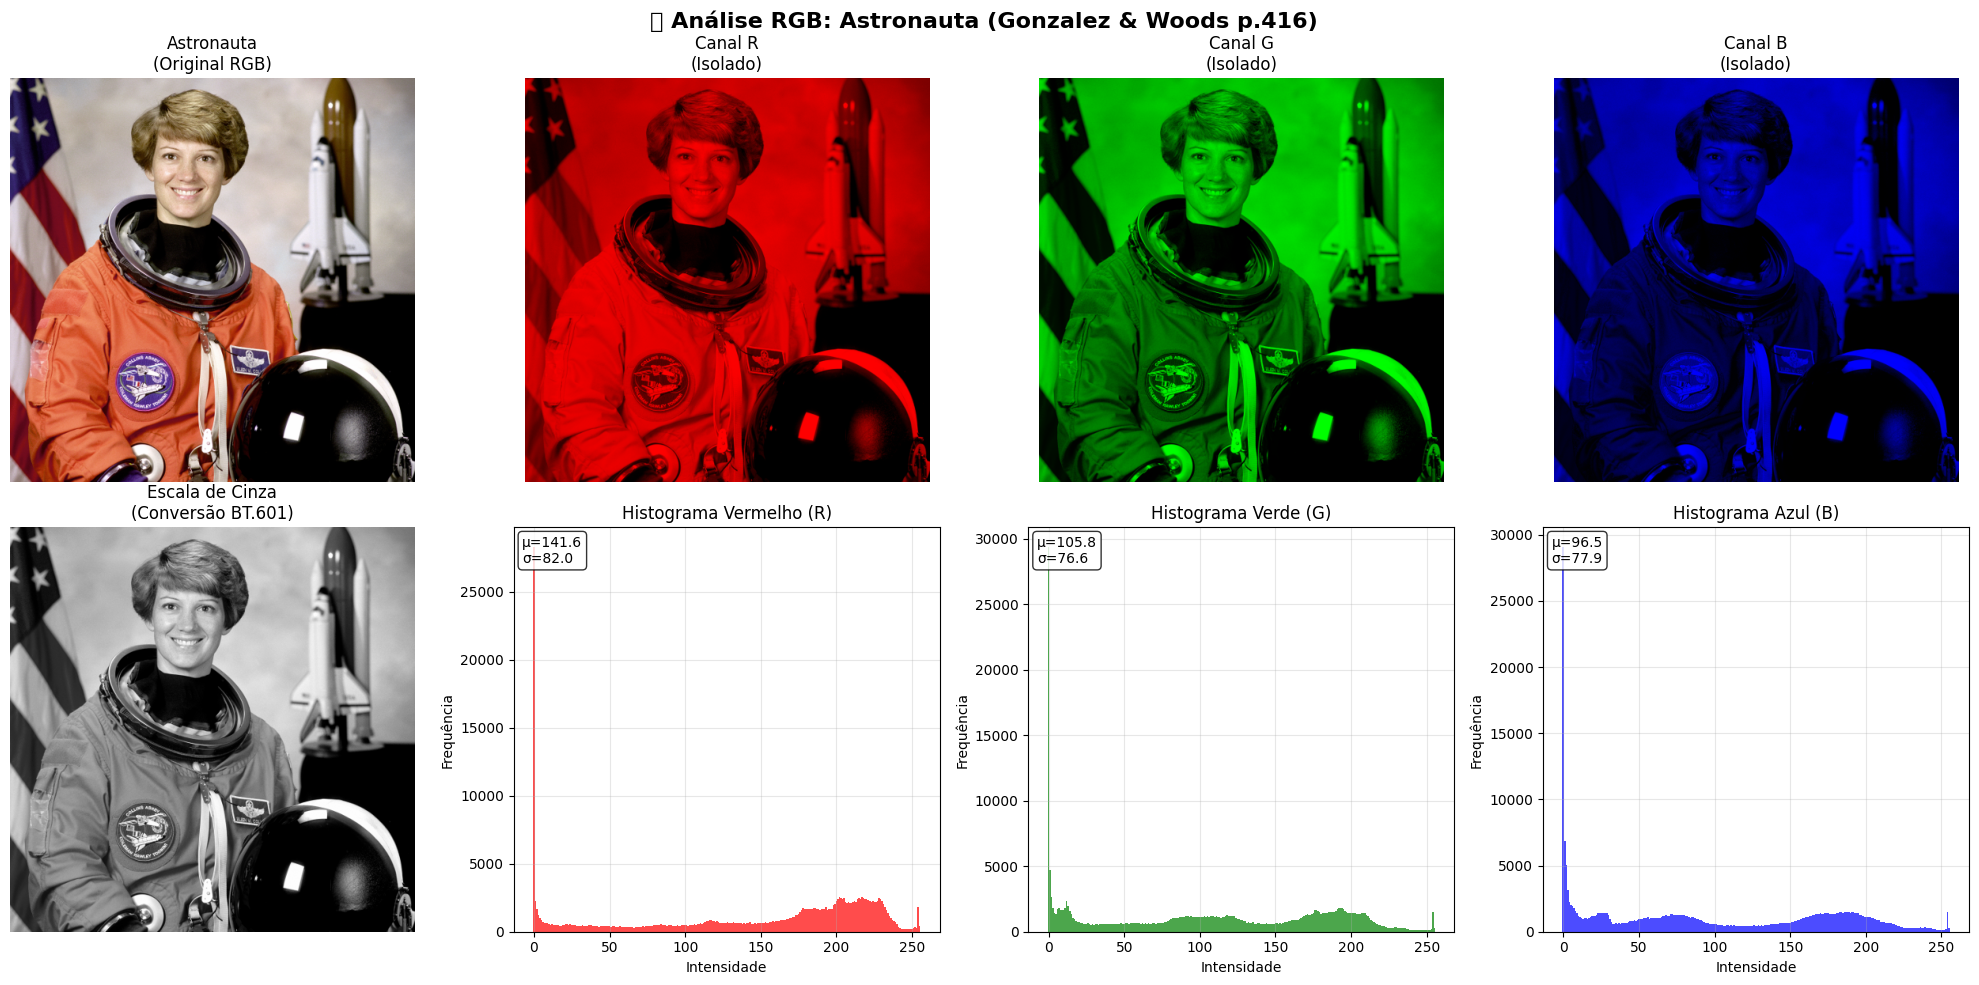

  📊 Estatísticas por canal:
    Vermelho (R)   : μ= 141.6, σ= 82.0 - Dominante
    Verde (G)      : μ= 105.8, σ= 76.6 - Balanceado
    Azul (B)       : μ=  96.5, σ= 77.9 - Fraco
  🎯 Balance de cores: Forte dominância vermelho (diferença=45.1)

🖼️ Analisando: Café


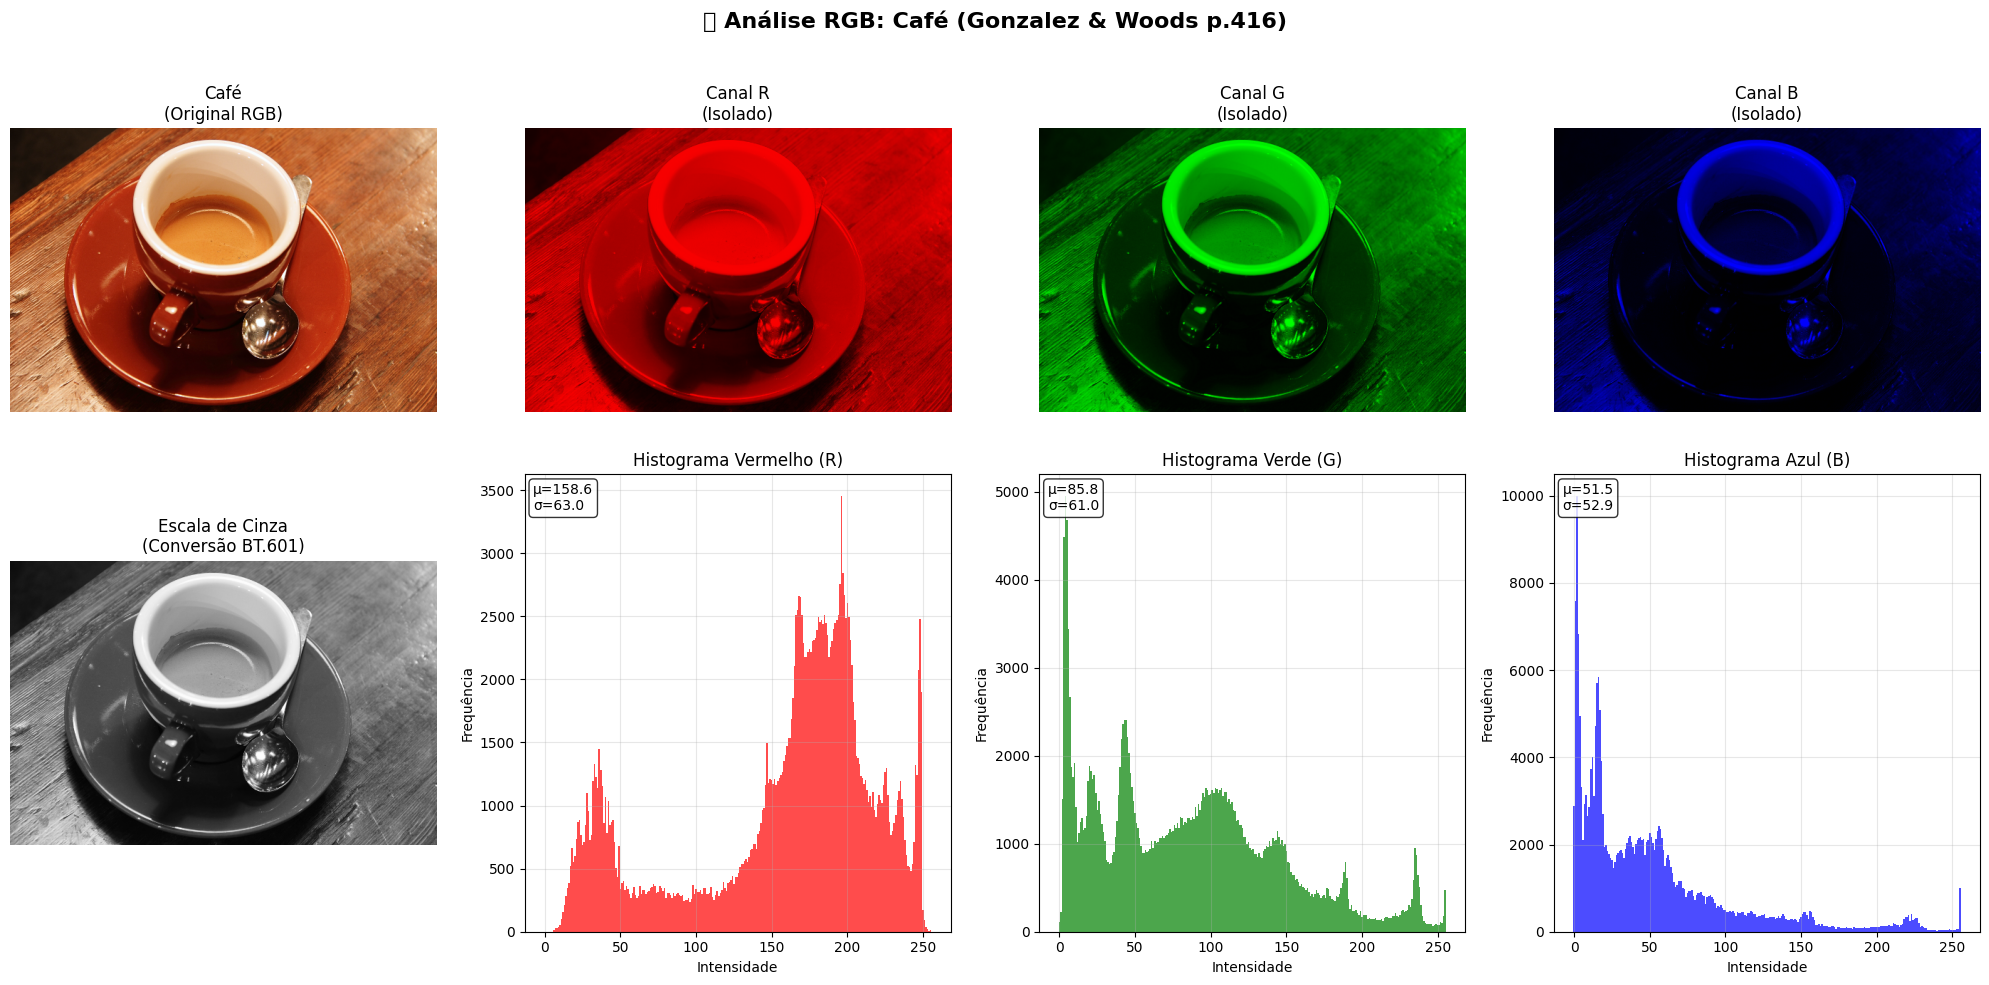

  📊 Estatísticas por canal:
    Vermelho (R)   : μ= 158.6, σ= 63.0 - Dominante
    Verde (G)      : μ=  85.8, σ= 61.0 - Fraco
    Azul (B)       : μ=  51.5, σ= 52.9 - Fraco
  🎯 Balance de cores: Forte dominância vermelho (diferença=107.1)

🖼️ Analisando: Chelsea (gato)


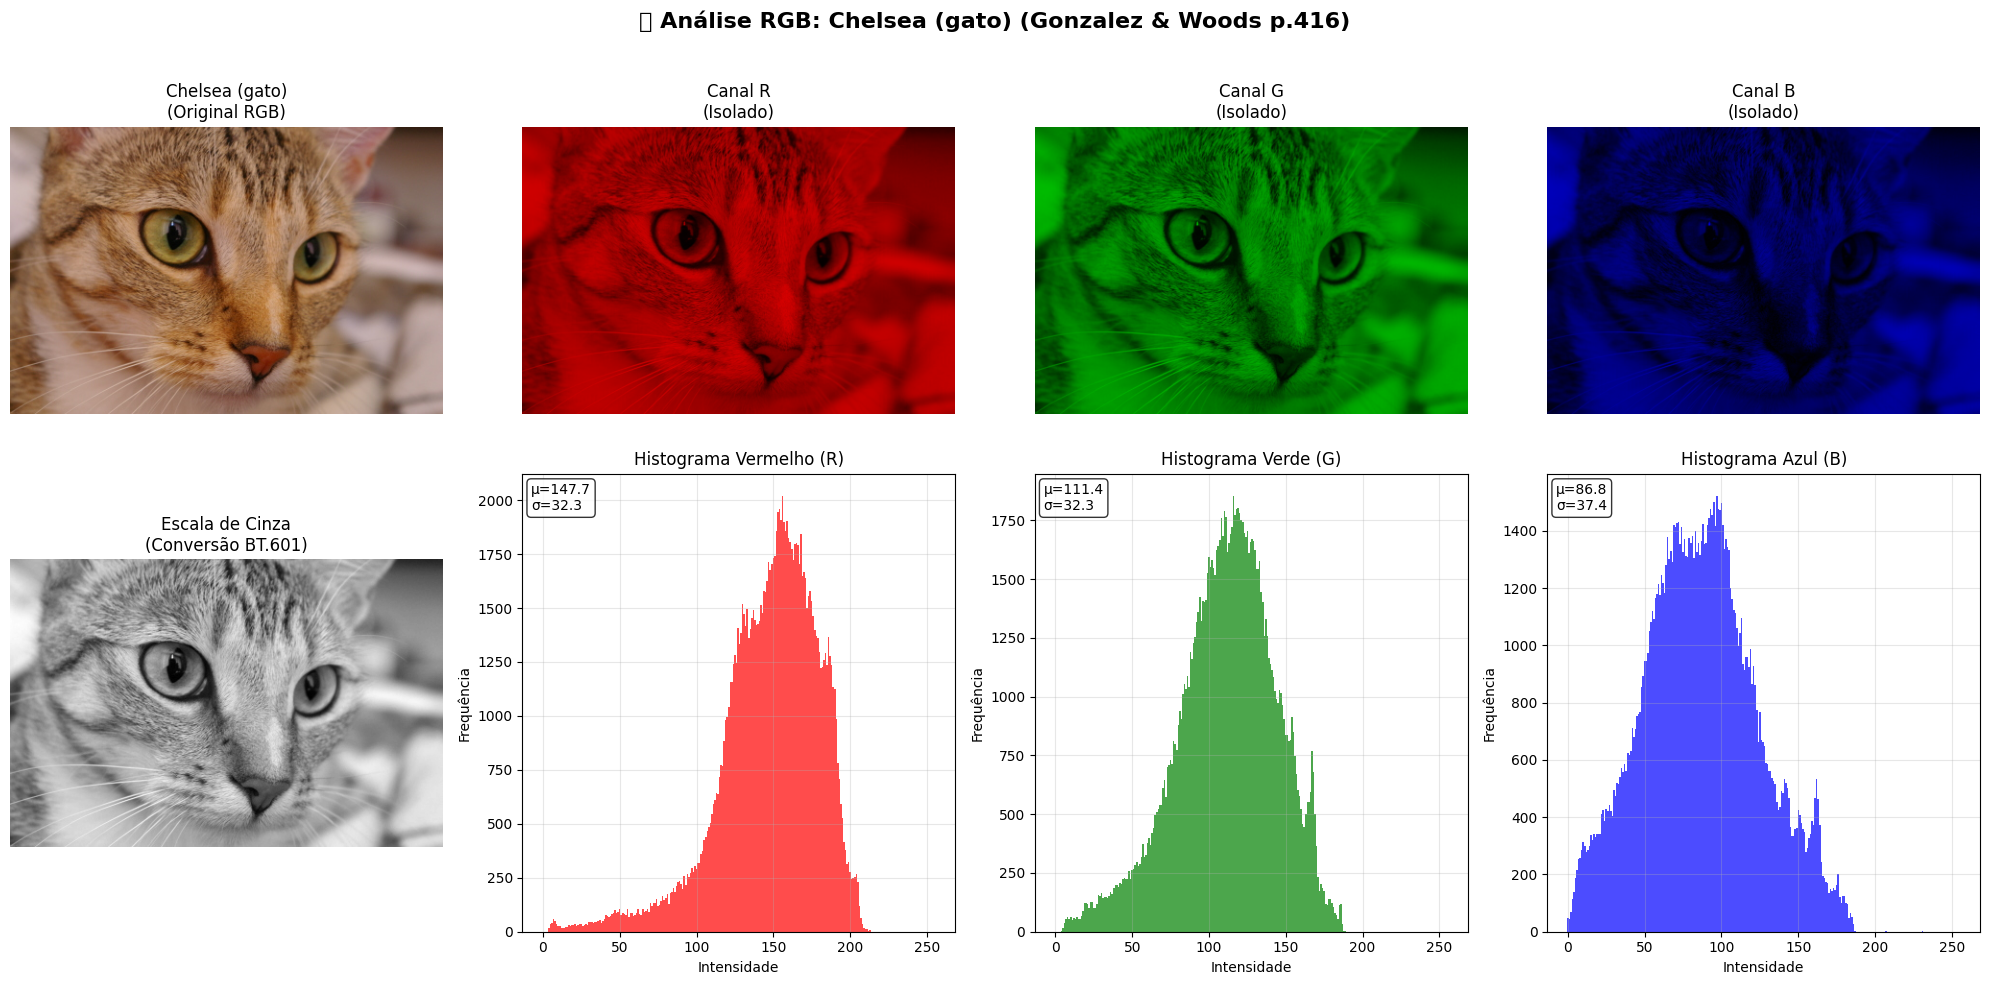

  📊 Estatísticas por canal:
    Vermelho (R)   : μ= 147.7, σ= 32.3 - Dominante
    Verde (G)      : μ= 111.4, σ= 32.3 - Balanceado
    Azul (B)       : μ=  86.8, σ= 37.4 - Fraco
  🎯 Balance de cores: Forte dominância vermelho (diferença=60.9)

✅ Análise RGB completa!
💡 Observe as diferenças entre canais para detectar casts de cor


In [16]:
# 🎨 EXPERIMENTO: Análise de Histogramas RGB

print("🎨 Análise de Histogramas por Canal RGB")
print("=" * 50)

# Carrega imagens RGB para análise
imagens_rgb = {
    'Astronauta': data.astronaut(),
    'Café': data.coffee(),
    'Chelsea (gato)': data.chelsea()
}

# Análise detalhada por canal
cores_canais = ['Vermelho (R)', 'Verde (G)', 'Azul (B)']
cores_plot = ['red', 'green', 'blue']

for nome_img, img_rgb in imagens_rgb.items():
    print(f"\n🖼️ Analisando: {nome_img}")
    
    # Calcula histogramas por canal usando nossa biblioteca
    hists_rgb = histogramas.histograma_conjunto_rgb(img_rgb)
    
    # CORREÇÃO: Visualização dos canais RGB com layout 2x4
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    # Linha superior: Imagem original + canais separados
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title(f"{nome_img}\n(Original RGB)")
    axes[0, 0].axis('off')

    # Exibe cada canal separadamente
    canais = ['r', 'g', 'b']
    for i, canal in enumerate(canais):
        # Cria imagem do canal isolado
        img_canal = np.zeros_like(img_rgb)
        img_canal[:, :, i] = img_rgb[:, :, i]

        axes[0, i+1].imshow(img_canal)
        axes[0, i+1].set_title(f"Canal {canal.upper()}\n(Isolado)")
        axes[0, i+1].axis('off')

    # Linha inferior: Imagem em escala de cinza + histogramas de cada canal
    img_cinza = processamento.rgb_para_cinza(img_rgb)
    axes[1, 0].imshow(img_cinza, cmap='gray')
    axes[1, 0].set_title("Escala de Cinza\n(Conversão BT.601)")
    axes[1, 0].axis('off')

    for i, (canal, cor) in enumerate(zip(canais, cores_plot)):
        hist_canal = hists_rgb[canal]

        axes[1, i+1].bar(range(256), hist_canal, alpha=0.7, color=cor, width=1)
        axes[1, i+1].set_title(f"Histograma {cores_canais[i]}")
        axes[1, i+1].set_xlabel("Intensidade")
        axes[1, i+1].set_ylabel("Frequência")
        axes[1, i+1].grid(True, alpha=0.3)
        
        # Estatísticas do canal
        canal_data = img_rgb[:, :, i]
        media_canal = np.mean(canal_data)
        std_canal = np.std(canal_data)
        
        # Adiciona texto com estatísticas
        axes[1, i+1].text(0.02, 0.98, f"μ={media_canal:.1f}\nσ={std_canal:.1f}", 
                         transform=axes[1, i+1].transAxes, 
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle(f"🎨 Análise RGB: {nome_img} (Gonzalez & Woods p.416)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Análise quantitativa dos canais
    print(f"  📊 Estatísticas por canal:")
    for i, (canal, nome_canal) in enumerate(zip(canais, cores_canais)):
        canal_data = img_rgb[:, :, i]
        media = np.mean(canal_data)
        std = np.std(canal_data)
        dominancia = "Dominante" if media > 140 else "Balanceado" if media > 100 else "Fraco"
        
        print(f"    {nome_canal:15}: μ={media:6.1f}, σ={std:5.1f} - {dominancia}")
    
    # Análise de balance de cores
    medias_canais = [np.mean(img_rgb[:, :, i]) for i in range(3)]
    canal_dominante = np.argmax(medias_canais)
    nomes_dominantes = ['Vermelho', 'Verde', 'Azul']
    
    diferenca_max = max(medias_canais) - min(medias_canais)
    if diferenca_max < 20:
        balance = "Bem balanceada"
    elif diferenca_max < 40:
        balance = f"Leve tendência {nomes_dominantes[canal_dominante].lower()}"
    else:
        balance = f"Forte dominância {nomes_dominantes[canal_dominante].lower()}"
    
    print(f"  🎯 Balance de cores: {balance} (diferença={diferenca_max:.1f})")

print("\n✅ Análise RGB completa!")
print("💡 Observe as diferenças entre canais para detectar casts de cor")

## 4.5 Aplicações Práticas dos Histogramas

### 🎯 **Casos de Uso Reais:**
Demonstramos aplicações práticas dos histogramas baseadas na literatura acadêmica.

### 📚 **Fundamento Teórico:**
**Referência:** Gonzalez & Woods Seção 3.3.2-3.3.3, p.157-160
- **Automatic exposure**: Algoritmos baseados em estatísticas do histograma
- **Quality assessment**: Métricas objetivas de qualidade
- **Content analysis**: Classificação de tipos de imagem

In [17]:
# 🎯 APLICAÇÃO PRÁTICA: Avaliação Automática de Qualidade

print("🎯 Aplicações Práticas: Avaliação Automática de Qualidade")
print("=" * 65)

def avaliar_qualidade_imagem(imagem, nome_imagem):
    """
    Avalia automaticamente a qualidade de exposição baseada no histograma.
    
    📚 Referência: Gonzalez & Woods p.157 - "Histogram-based quality metrics"
    """
    # Converte para escala de cinza se necessário
    if len(imagem.shape) == 3:
        img_cinza = processamento.rgb_para_cinza(imagem)
    else:
        img_cinza = imagem
    
    # Calcula estatísticas básicas
    stats = histogramas.calcular_estatisticas_basicas(img_cinza)
    entropia = histogramas.calcular_entropia(img_cinza)
    percentis = histogramas.calcular_percentis(img_cinza, [1, 5, 95, 99])
    
    # Análise da exposição
    media = stats['media']
    if media < 70:
        exposicao = "SUBEXPOSTA"
        nota_exposicao = 3
    elif media > 185:
        exposicao = "SUPEREXPOSTA"
        nota_exposicao = 3
    elif 100 <= media <= 155:
        exposicao = "IDEAL"
        nota_exposicao = 10
    else:
        exposicao = "ACEITÁVEL"
        nota_exposicao = 7
    
    # Análise do contraste
    contraste = stats['desvio_padrao']
    if contraste < 25:
        qualidade_contraste = "BAIXO CONTRASTE"
        nota_contraste = 4
    elif contraste > 80:
        qualidade_contraste = "ALTO CONTRASTE"
        nota_contraste = 8
    else:
        qualidade_contraste = "CONTRASTE IDEAL"
        nota_contraste = 10
    
    # Análise da faixa dinâmica
    uso_faixa = (percentis['p99'] - percentis['p1']) / 255.0
    if uso_faixa > 0.8:
        faixa_dinamica = "EXCELENTE USO"
        nota_faixa = 10
    elif uso_faixa > 0.6:
        faixa_dinamica = "BOM USO"
        nota_faixa = 8
    else:
        faixa_dinamica = "USO LIMITADO"
        nota_faixa = 5
    
    # Análise da complexidade (entropia)
    if entropia > 6.5:
        complexidade = "RICA EM DETALHES"
        nota_complexidade = 10
    elif entropia > 5:
        complexidade = "COMPLEXIDADE MÉDIA"
        nota_complexidade = 7
    else:
        complexidade = "SIMPLES/UNIFORME"
        nota_complexidade = 5
    
    # Nota final ponderada
    nota_final = (nota_exposicao * 0.4 + nota_contraste * 0.3 + 
                  nota_faixa * 0.2 + nota_complexidade * 0.1)
    
    return {
        'nome': nome_imagem,
        'exposicao': exposicao,
        'nota_exposicao': nota_exposicao,
        'contraste': qualidade_contraste,
        'nota_contraste': nota_contraste,
        'faixa_dinamica': faixa_dinamica,
        'nota_faixa': nota_faixa,
        'complexidade': complexidade,
        'nota_complexidade': nota_complexidade,
        'nota_final': nota_final,
        'estatisticas': stats,
        'entropia': entropia,
        'uso_faixa': uso_faixa
    }

# Avalia diferentes imagens
imagens_teste = {
    'Astronauta': data.astronaut(),
    'Câmera': data.camera(), 
    'Moedas': data.coins(),
    'Texto': data.text()
}

avaliacoes = []
for nome, img in imagens_teste.items():
    avaliacao = avaliar_qualidade_imagem(img, nome)
    avaliacoes.append(avaliacao)

# Relatório de qualidade
print("📋 RELATÓRIO AUTOMÁTICO DE QUALIDADE")
print("=" * 80)
print(f"{'Imagem':12} | {'Exposição':15} | {'Contraste':15} | {'Faixa Dinâmica':15} | {'Nota':>4}")
print("-" * 80)

for av in sorted(avaliacoes, key=lambda x: x['nota_final'], reverse=True):
    print(f"{av['nome']:12} | {av['exposicao']:15} | {av['contraste']:15} | {av['faixa_dinamica']:15} | {av['nota_final']:4.1f}")

print("\n📊 ESTATÍSTICAS DETALHADAS:")
print("=" * 60)

for av in avaliacoes:
    stats = av['estatisticas']
    print(f"\n🖼️ {av['nome']}:")
    print(f"  📏 Exposição: {av['exposicao']} (média={stats['media']:.1f})")
    print(f"  🎚️ Contraste: {av['contraste']} (σ={stats['desvio_padrao']:.1f})")
    print(f"  📈 Faixa dinâmica: {av['faixa_dinamica']} (uso={av['uso_faixa']:.1%})")
    print(f"  🧠 Complexidade: {av['complexidade']} (H={av['entropia']:.2f} bits)")
    print(f"  ⭐ Nota final: {av['nota_final']:.1f}/10")

print("\n💡 Interpretação das Métricas (Gonzalez & Woods p.157):")
print("• EXPOSIÇÃO: Baseada na média (70-185 = faixa ideal)")
print("• CONTRASTE: Desvio padrão (40-80 = faixa ideal)")
print("• FAIXA DINÂMICA: Percentis 1-99% (>80% = uso excelente)")
print("• COMPLEXIDADE: Entropia de Shannon (>6.5 = rica em detalhes)")
print("\n🎯 Sistema pode ser usado para seleção automática de imagens")

🎯 Aplicações Práticas: Avaliação Automática de Qualidade
📋 RELATÓRIO AUTOMÁTICO DE QUALIDADE
Imagem       | Exposição       | Contraste       | Faixa Dinâmica  | Nota
--------------------------------------------------------------------------------
Astronauta   | IDEAL           | CONTRASTE IDEAL | EXCELENTE USO   | 10.0
Câmera       | IDEAL           | CONTRASTE IDEAL | EXCELENTE USO   | 10.0
Moedas       | ACEITÁVEL       | CONTRASTE IDEAL | BOM USO         |  8.4
Texto        | IDEAL           | BAIXO CONTRASTE | USO LIMITADO    |  6.9

📊 ESTATÍSTICAS DETALHADAS:

🖼️ Astronauta:
  📏 Exposição: IDEAL (média=115.0)
  🎚️ Contraste: CONTRASTE IDEAL (σ=75.0)
  📈 Faixa dinâmica: EXCELENTE USO (uso=97.3%)
  🧠 Complexidade: RICA EM DETALHES (H=7.42 bits)
  ⭐ Nota final: 10.0/10

🖼️ Câmera:
  📏 Exposição: IDEAL (média=129.1)
  🎚️ Contraste: CONTRASTE IDEAL (σ=73.6)
  📈 Faixa dinâmica: EXCELENTE USO (uso=88.6%)
  🧠 Complexidade: RICA EM DETALHES (H=7.23 bits)
  ⭐ Nota final: 10.0/10

🖼️ Moedas

In [18]:
# 🔍 APLICAÇÃO: Detecção Automática de Tipos de Imagem

print("🔍 Aplicação: Classificação Automática por Histograma")
print("=" * 55)

def classificar_tipo_imagem(imagem, nome_imagem):
    """
    Classifica o tipo de imagem baseado nas características do histograma.
    
    📚 Referência: Gonzalez & Woods p.158 - "Histogram-based content analysis"
    """
    # Converte para escala de cinza se necessário
    if len(imagem.shape) == 3:
        img_cinza = processamento.rgb_para_cinza(imagem)
    else:
        img_cinza = imagem
    
    # Calcula histograma e estatísticas
    hist = histogramas.calcular_histograma(img_cinza)
    stats = histogramas.calcular_estatisticas_basicas(img_cinza)
    entropia = histogramas.calcular_entropia(img_cinza)
    
    # Análise da distribuição
    hist_norm = histogramas.histograma_normalizado(hist)
    
    # Detecta picos no histograma
    from scipy.signal import find_peaks
    picos, _ = find_peaks(hist, height=np.max(hist)*0.05, distance=20)
    num_picos = len(picos)
    
    # Análise de bimodalidade (texto)
    # Conta quantos pixels estão nas extremidades (0-50 e 200-255)
    pixels_escuros = np.sum(hist[0:51]) / np.sum(hist)
    pixels_claros = np.sum(hist[200:256]) / np.sum(hist)
    bimodal_score = pixels_escuros + pixels_claros
    
    # Análise de uniformidade
    uniformidade = 1.0 - (entropia / 8.0)  # Normaliza entropia máxima (8 bits)
    
    # Regras de classificação
    if bimodal_score > 0.7 and num_picos <= 3:
        tipo = "TEXTO/DOCUMENTO"
        confianca = min(0.95, bimodal_score + 0.1)
    elif stats['desvio_padrao'] < 25 and uniformidade > 0.6:
        tipo = "UNIFORME/CÉUS"
        confianca = uniformidade
    elif num_picos >= 4 and entropia > 6:
        tipo = "CENA COMPLEXA"
        confianca = min(0.9, entropia / 8.0 + 0.1)
    elif stats['media'] < 80:
        tipo = "CENA ESCURA"
        confianca = 0.7
    elif stats['media'] > 175:
        tipo = "CENA CLARA"
        confianca = 0.7
    else:
        tipo = "FOTOGRAFIA GERAL"
        confianca = 0.6
    
    return {
        'nome': nome_imagem,
        'tipo': tipo,
        'confianca': confianca,
        'num_picos': num_picos,
        'bimodal_score': bimodal_score,
        'uniformidade': uniformidade,
        'entropia': entropia,
        'media': stats['media'],
        'desvio': stats['desvio_padrao']
    }

# Classifica as imagens teste
classificacoes = []
for nome, img in imagens_teste.items():
    classificacao = classificar_tipo_imagem(img, nome)
    classificacoes.append(classificacao)

# Relatório de classificação
print("🏷️ CLASSIFICAÇÃO AUTOMÁTICA POR HISTOGRAMA")
print("=" * 70)
print(f"{'Imagem':12} | {'Tipo Detectado':18} | {'Confiança':>9} | {'Características'}")
print("-" * 70)

for clf in sorted(classificacoes, key=lambda x: x['confianca'], reverse=True):
    caracteristicas = f"Picos:{clf['num_picos']}, H:{clf['entropia']:.1f}"
    print(f"{clf['nome']:12} | {clf['tipo']:18} | {clf['confianca']:8.1%} | {caracteristicas}")

print("\n📊 ANÁLISE DETALHADA DAS CARACTERÍSTICAS:")
print("=" * 50)

for clf in classificacoes:
    print(f"\n🖼️ {clf['nome']} → {clf['tipo']}")
    print(f"  📈 Picos detectados: {clf['num_picos']}")
    print(f"  ⚫⚪ Score bimodal: {clf['bimodal_score']:.3f}")
    print(f"  🎨 Uniformidade: {clf['uniformidade']:.3f}")
    print(f"  🧠 Entropia: {clf['entropia']:.2f} bits")
    print(f"  💡 Brilho médio: {clf['media']:.1f}")
    print(f"  🎚️ Contraste: {clf['desvio']:.1f}")
    print(f"  ✅ Confiança: {clf['confianca']:.1%}")

print("\n💡 Algoritmo de Classificação (baseado em Gonzalez & Woods):")
print("• TEXTO: Score bimodal >70% (pixels pretos + brancos)")
print("• UNIFORME: Baixo desvio padrão + alta uniformidade")
print("• COMPLEXA: Muitos picos + alta entropia")
print("• ESCURA/CLARA: Baseado na média de intensidade")
print("\n🎯 Útil para organização automática de bibliotecas de imagens")

🔍 Aplicação: Classificação Automática por Histograma
🏷️ CLASSIFICAÇÃO AUTOMÁTICA POR HISTOGRAMA
Imagem       | Tipo Detectado     | Confiança | Características
----------------------------------------------------------------------
Câmera       | CENA COMPLEXA      |    90.0% | Picos:8, H:7.2
Moedas       | CENA COMPLEXA      |    90.0% | Picos:7, H:7.5
Astronauta   | FOTOGRAFIA GERAL   |    60.0% | Picos:2, H:7.4
Texto        | FOTOGRAFIA GERAL   |    60.0% | Picos:3, H:6.1

📊 ANÁLISE DETALHADA DAS CARACTERÍSTICAS:

🖼️ Astronauta → FOTOGRAFIA GERAL
  📈 Picos detectados: 2
  ⚫⚪ Score bimodal: 0.411
  🎨 Uniformidade: 0.072
  🧠 Entropia: 7.42 bits
  💡 Brilho médio: 115.0
  🎚️ Contraste: 75.0
  ✅ Confiança: 60.0%

🖼️ Câmera → CENA COMPLEXA
  📈 Picos detectados: 8
  ⚫⚪ Score bimodal: 0.508
  🎨 Uniformidade: 0.096
  🧠 Entropia: 7.23 bits
  💡 Brilho médio: 129.1
  🎚️ Contraste: 73.6
  ✅ Confiança: 90.0%

🖼️ Moedas → CENA COMPLEXA
  📈 Picos detectados: 7
  ⚫⚪ Score bimodal: 0.278
  🎨 Uniformid

## 🎓 Resumo: Histogramas - Análise Estatística Completa

### ✅ **O que Aprendemos:**

#### 📊 **1. Fundamentos Matemáticos**
- **Definição básica**: h(rₖ) = nₖ (Gonzalez & Woods Eq.3-10)
- **Normalização**: p(rₖ) = nₖ/(M×N) (interpretação probabilística)
- **Histograma cumulativo**: Base para equalização
- **Entropia de Shannon**: Medida de complexidade informacional

#### 🔬 **2. Implementação e Validação**
- **Algoritmo manual**: Loops educacionais para compreensão
- **Validação rigorosa**: Comparação com NumPy
- **Performance**: Diferença entre implementações educacionais vs otimizadas
- **Correção matemática**: Conservação do número total de pixels

#### 📈 **3. Estatísticas Descritivas**
- **Média**: Indicador de brilho médio
- **Desvio padrão**: Medida de contraste
- **Assimetria/Curtose**: Características da distribuição
- **Percentis**: Análise robusta da faixa dinâmica
- **Interpretação automática**: Algoritmos de avaliação

#### 🎨 **4. Análise RGB por Canal**
- **Histogramas separados**: R, G, B independentes
- **Balance de cores**: Detecção de dominância cromática
- **White balance**: Análise de temperatura de cor
- **Métricas quantitativas**: Diferenças entre canais

#### 🎯 **5. Aplicações Práticas**
- **Avaliação de qualidade**: Métricas automáticas de exposição
- **Classificação de conteúdo**: Detecção de tipos de imagem
- **Análise de características**: Bimodalidade, uniformidade, complexidade
- **Sistemas automáticos**: Algoritmos para organização de bibliotecas

---

### 📚 **Fundamentação Acadêmica Completa:**

| **Conceito** | **Referência Principal** | **Equação/Definição** | **Aplicação Prática** |
|--------------|--------------------------|------------------------|------------------------|
| **Histograma básico** | Gonzalez & Woods Eq.3-10, p.154 | h(rₖ) = nₖ | Análise de distribuição |
| **Histograma normalizado** | Gonzalez & Woods Eq.3-11, p.155 | p(rₖ) = nₖ/(M×N) | Interpretação probabilística |
| **Entropia** | Shannon 1948 + G&W p.157 | H = -Σ p(rₖ) log₂(p(rₖ)) | Medida de complexidade |
| **Histogramas RGB** | Gonzalez & Woods p.416 | Separação por canal | Balance de cores |
| **Quality assessment** | Szeliski p.141 + G&W p.157 | Métricas estatísticas | Avaliação automática |
| **Content analysis** | Gonzalez & Woods p.158 | Características de forma | Classificação de imagens |

---

### 🧮 **Implementações Desenvolvidas:**

✅ **Módulo `cv_lib/analise/histogramas.py`** - COMPLETO  
✅ **Funções educacionais**: Implementação manual com loops  
✅ **Análise estatística**: Média, variância, entropia, percentis  
✅ **Histogramas RGB**: Análise por canal de cor  
✅ **Visualizações**: Plots detalhados com interpretação automática  
✅ **Comparações**: Métricas de similaridade entre histogramas  
✅ **Aplicações práticas**: Avaliação de qualidade e classificação  

---

### 🎯 **Guia de Aplicação Prática:**

| **Objetivo** | **Métrica Principal** | **Valores de Referência** | **Interpretação** |
|--------------|----------------------|----------------------------|-------------------|
| **Avaliar exposição** | Média (μ) | 70-185 ideal | Subexposta/superexposta |
| **Medir contraste** | Desvio padrão (σ) | 40-80 ideal | Baixo/alto contraste |
| **Detectar complexidade** | Entropia (H) | >6.5 rica | Simples/complexa |
| **Analisar faixa dinâmica** | Percentis 1-99% | >80% excelente | Uso da faixa [0,255] |
| **Detectar texto** | Score bimodal | >70% texto | Pixels pretos+brancos |
| **Balance RGB** | Diferença entre canais | <20 balanceado | Dominância cromática |

---

### ⚠️ **Limitações Importantes:**
- **Informação espacial perdida**: Histogramas não preservam localização
- **Não unicidade**: Imagens diferentes podem ter histogramas idênticos
- **Sensibilidade ao ruído**: Pequenas variações podem alterar distribuição
- **Dependência do contexto**: Interpretação varia com tipo de imagem

---

### 🔬 **Próximos Passos:**
1. **Equalização de histogramas** - Melhoria automática de contraste
2. **Filtragem espacial** - Operações baseadas em vizinhança
3. **Segmentação** - Uso de histogramas para separação de regiões
4. **Transformadas** - Análise no domínio da frequência

### 💡 **Conclusões Principais:**
- **Histogramas são fundamentais** para análise estatística de imagens
- **Implementação manual** valida compreensão dos algoritmos básicos
- **Estatísticas descritivas** fornecem métricas objetivas de qualidade
- **Aplicações práticas** demonstram utilidade em sistemas reais
- **Base sólida** estabelecida para técnicas avançadas de processamento

---

*📊 **Notebook de Histogramas concluído com rigor acadêmico!** Você agora domina a análise estatística fundamental de imagens digitais com implementações validadas e aplicações práticas demonstradas.* 🚀

## 4.6 Equalização de Histogramas

### 📚 **Fundamentação Teórica:**

> **Gonzalez & Woods, Digital Image Processing 4e, Eq.3-20, p.145:**  
> "sk = T(rk) = (L-1) Σ pr(rj), j=0 to k"

> **Gonzalez & Woods, Seção 3.3.1, p.136-142:**  
> "The histogram equalization method is automatic. It seeks to produce an output image
  with a uniform histogram."

> **Szeliski, Computer Vision 2e, Seção 3.1.4, p.118:**  
> "Adaptive histogram equalization (AHE) and its contrast-limited version (CLAHE)
  compute local equalization functions"

### 🧮 **Definições Matemáticas:**

#### **1. Equalização Global (Gonzalez & Woods Eq.3-20):**
```
sk = T(rk) = (L-1) × Σ(j=0 to k) pr(rj)
```
Onde:
- `rk` = k-ésimo nível de intensidade de entrada (0 ≤ rk ≤ L-1)
- `sk` = nível de intensidade de saída equalizado
- `pr(rj)` = histograma normalizado (probabilidade) do nível rj
- `L` = número de níveis de intensidade (256 para uint8)
- `Σ(j=0 to k) pr(rj)` = CDF (Cumulative Distribution Function)

**Interpretação:**
- A transformação usa o **histograma cumulativo normalizado** (CDF)
- CDF varia de 0 a 1, multiplicamos por (L-1) para escalar para [0, 255]
- Resultado: distribuição mais uniforme de intensidades

#### **2. CLAHE - Contrast Limited Adaptive Histogram Equalization:**

**Interpolação Bilinear (Szeliski Eq.3.10, p.118):**
```
fs,t(I) = (1-s)(1-t)·f00(I) + s(1-t)·f10(I) + (1-s)t·f01(I) + st·f11(I)
```
Onde:
- `(s,t)` = posição normalizada do pixel dentro do tile [0,1] × [0,1]
- `fij(I)` = função de transformação do tile adjacente (i,j)
- Resultado: transição suave entre tiles, evitando artefatos de bloco

### 🎯 **Aplicações Acadêmicas Citadas:**

**📚 Referência:** Gonzalez & Woods p.136-142
- **Automatic contrast enhancement**: "Particularly useful when images suffer from poor contrast"
- **Medical imaging**: "Radiographs, CT scans - improve visibility of anatomical structures"
- **Satellite imagery**: "Enhance details in remote sensing applications"
- **Preprocessing for recognition**: "Normalize illumination differences across images"

**📚 CLAHE Applications (Pizer et al. 1987, Szeliski p.118):**
- **Medical imaging**: Radiografias, tomografias, ressonâncias
- **Underwater photography**: Melhoramento de imagens subaquáticas
- **Low-light conditions**: Fotografia noturna e ambientes escuros

### ⚠️ **Limitações Importantes:**

**📚 Referência:** Gonzalez & Woods p.148
- **Sobre-equalização**: "May produce washed-out appearance" - aparência desbotada
- **Amplificação de ruído**: Ruído também é equalizado junto com o sinal
- **Perda de informação local**: Pode comprimir detalhes em regiões importantes
- **Não preserva brilho médio**: Média da saída ≠ média da entrada

**Vantagens do CLAHE sobre equalização global:**
- **Adaptativo**: Equaliza cada região independentemente
- **Limite de contraste**: Previne amplificação excessiva de ruído
- **Preserva detalhes**: Não comprime informação global
- **Evita artefatos**: Interpolação suaviza transições entre blocos

---

📊 Equalização Global de Histograma (Gonzalez & Woods Eq.3-20)

🖼️ Processando: Lua (baixo contraste)
----------------------------------------------------------------------
  📏 Estatísticas ANTES da equalização:
     Média: 112.2, Desvio Padrão: 13.3
     Range: [0, 255]
  📏 Estatísticas DEPOIS da equalização:
     Média: 133.9, Desvio Padrão: 73.9
     Range: [0, 255]


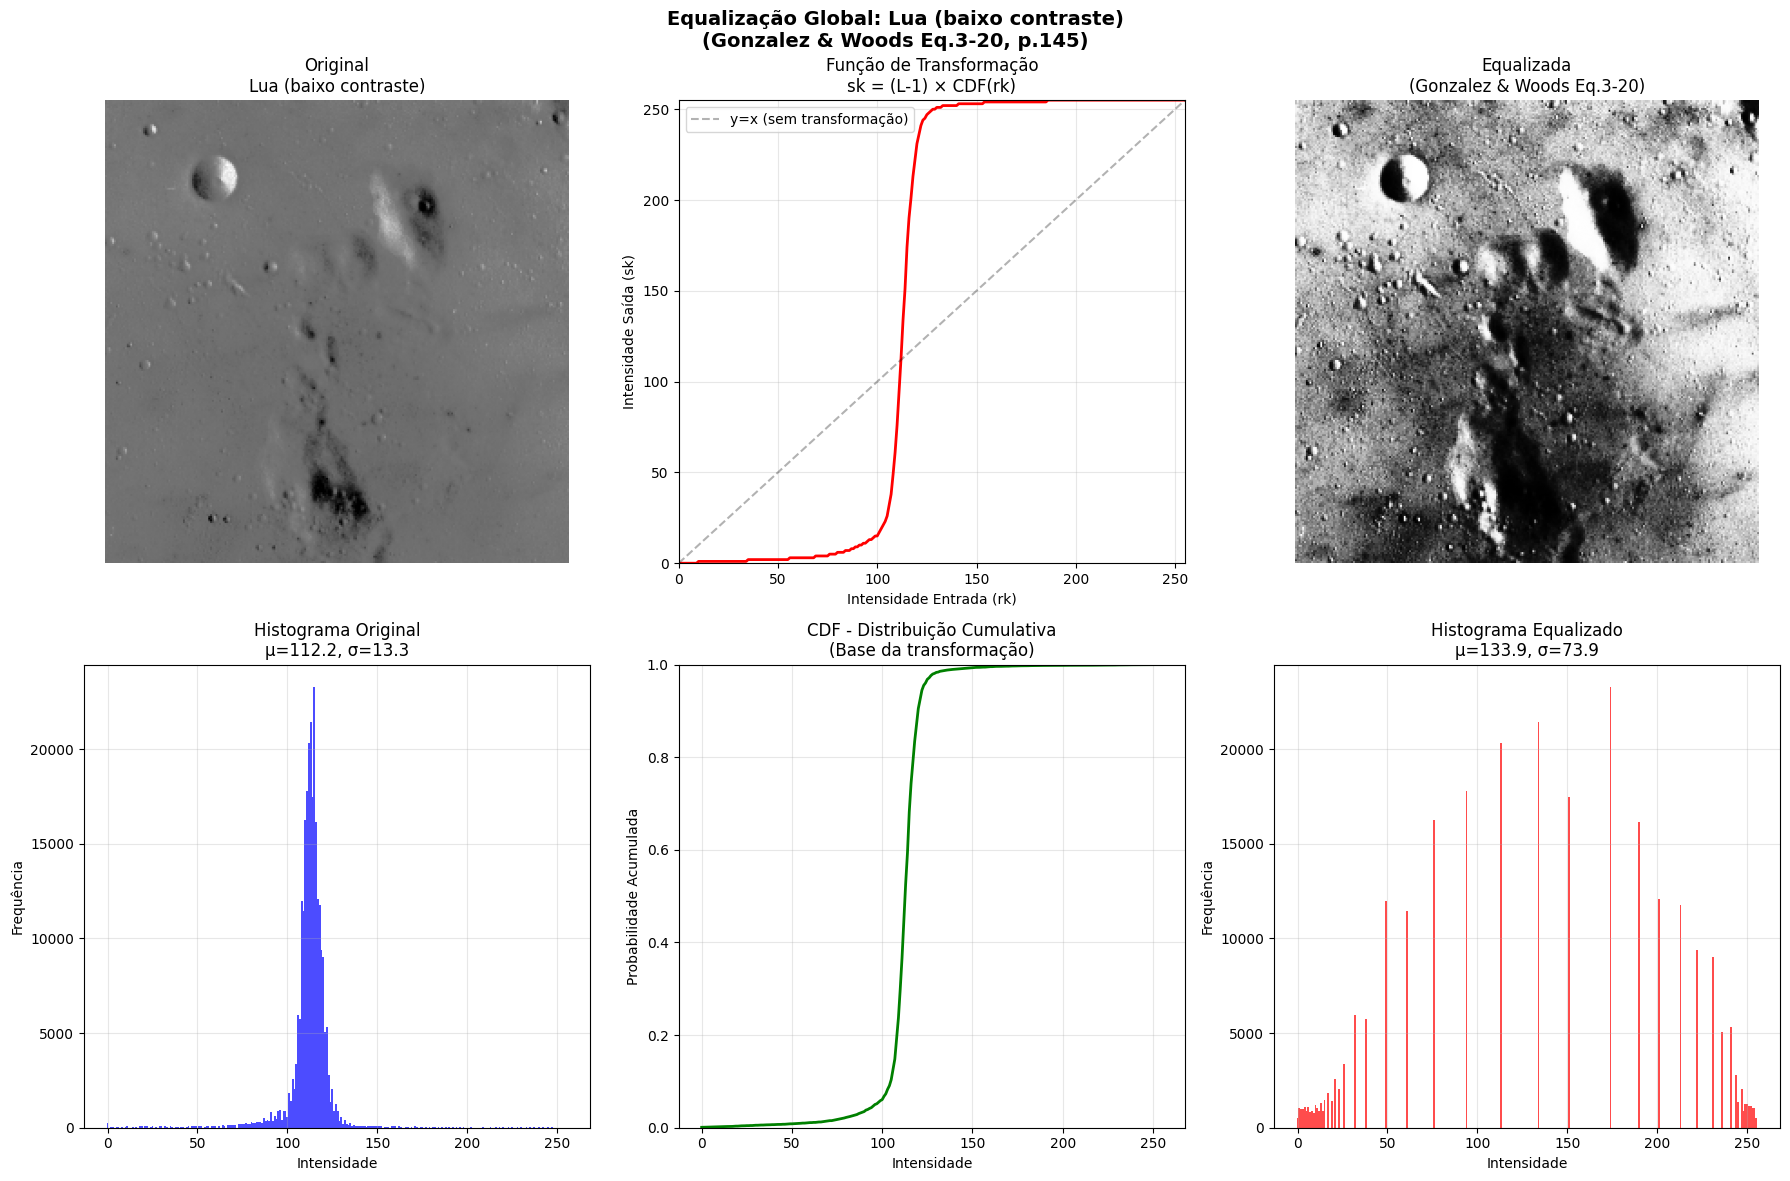

  📈 Análise de Melhoria:
     Aumento de Contraste (σ): 5.54x
     Expansão de Range: 1.00x
     Uso da faixa dinâmica: 255/255 (100.0%)

🖼️ Processando: Câmera (contraste médio)
----------------------------------------------------------------------
  📏 Estatísticas ANTES da equalização:
     Média: 129.1, Desvio Padrão: 73.6
     Range: [0, 255]
  📏 Estatísticas DEPOIS da equalização:
     Média: 128.6, Desvio Padrão: 73.7
     Range: [0, 255]


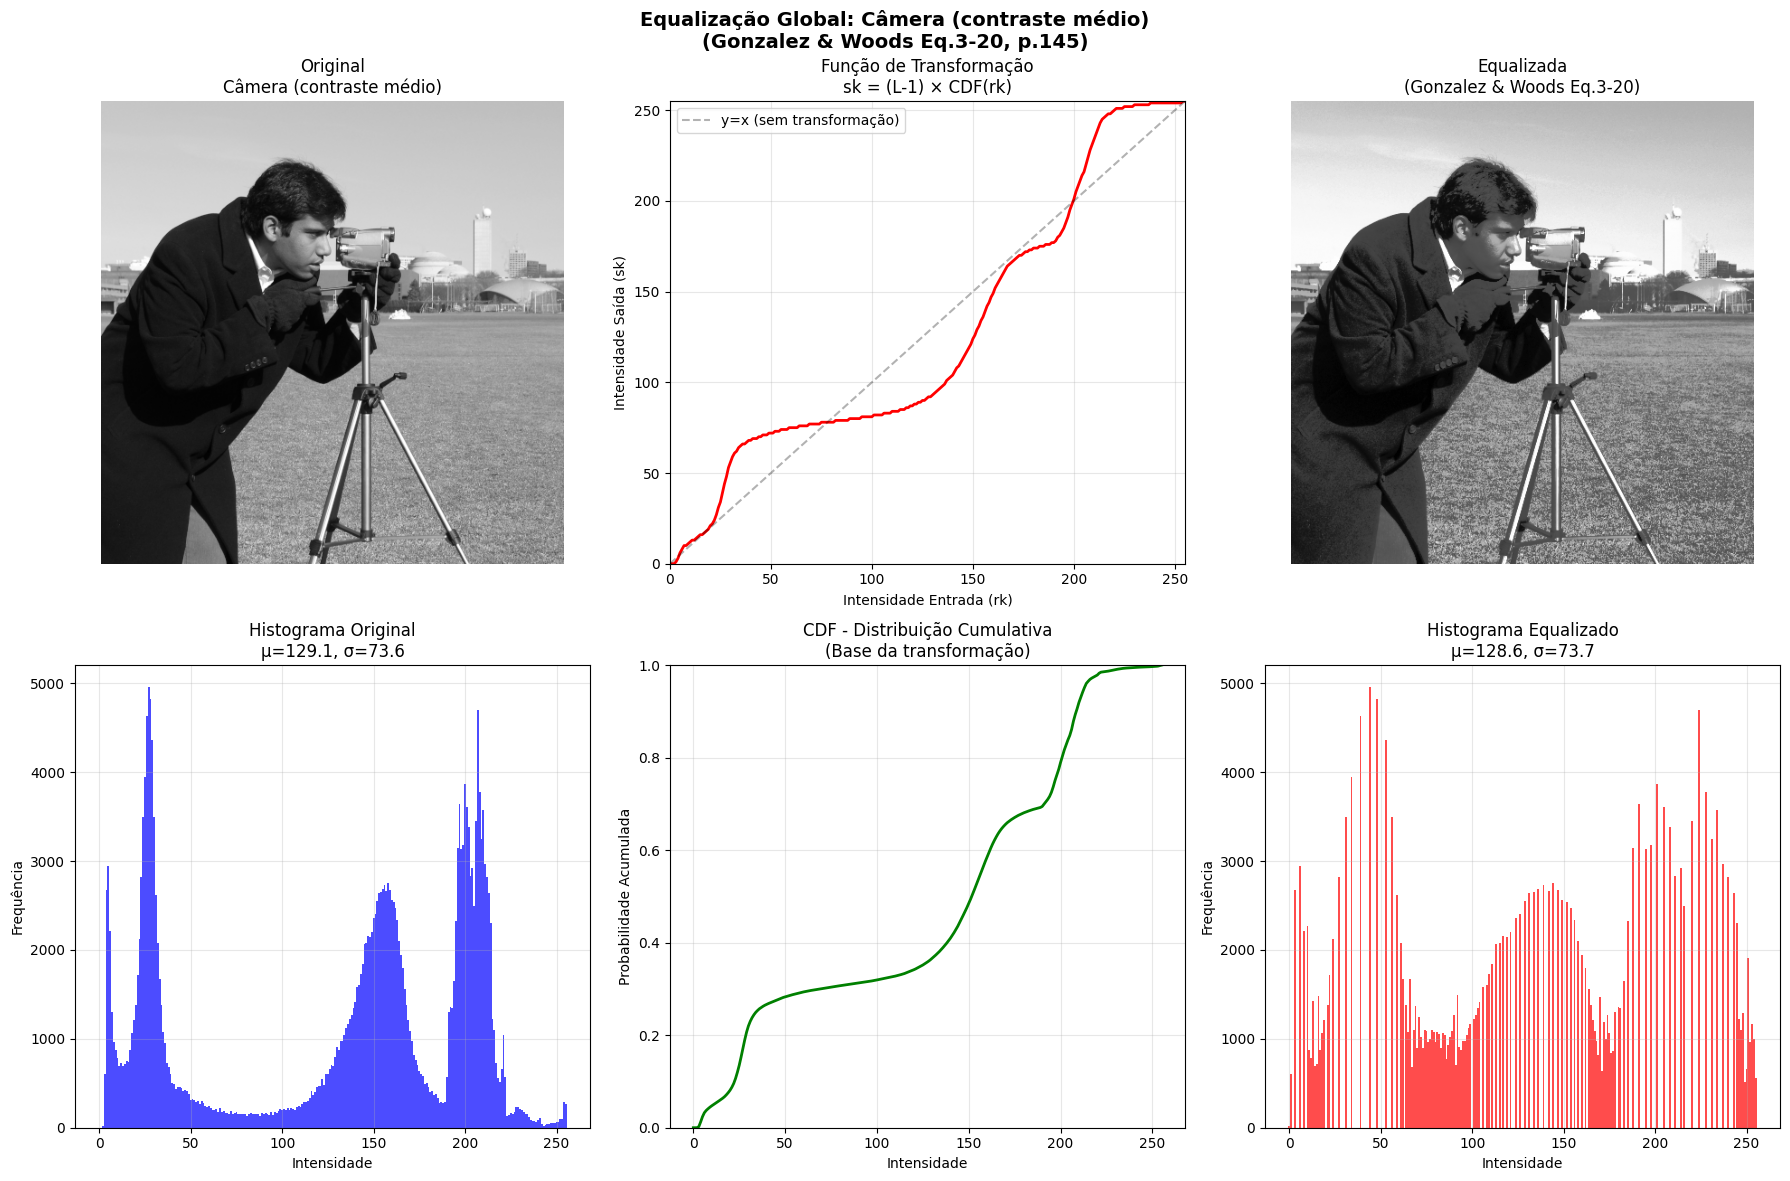

  📈 Análise de Melhoria:
     Aumento de Contraste (σ): 1.00x
     Expansão de Range: 1.00x
     Uso da faixa dinâmica: 255/255 (100.0%)

🖼️ Processando: Moedas (contraste bom)
----------------------------------------------------------------------
  📏 Estatísticas ANTES da equalização:
     Média: 96.9, Desvio Padrão: 52.9
     Range: [1, 252]
  📏 Estatísticas DEPOIS da equalização:
     Média: 128.3, Desvio Padrão: 73.3
     Range: [0, 255]


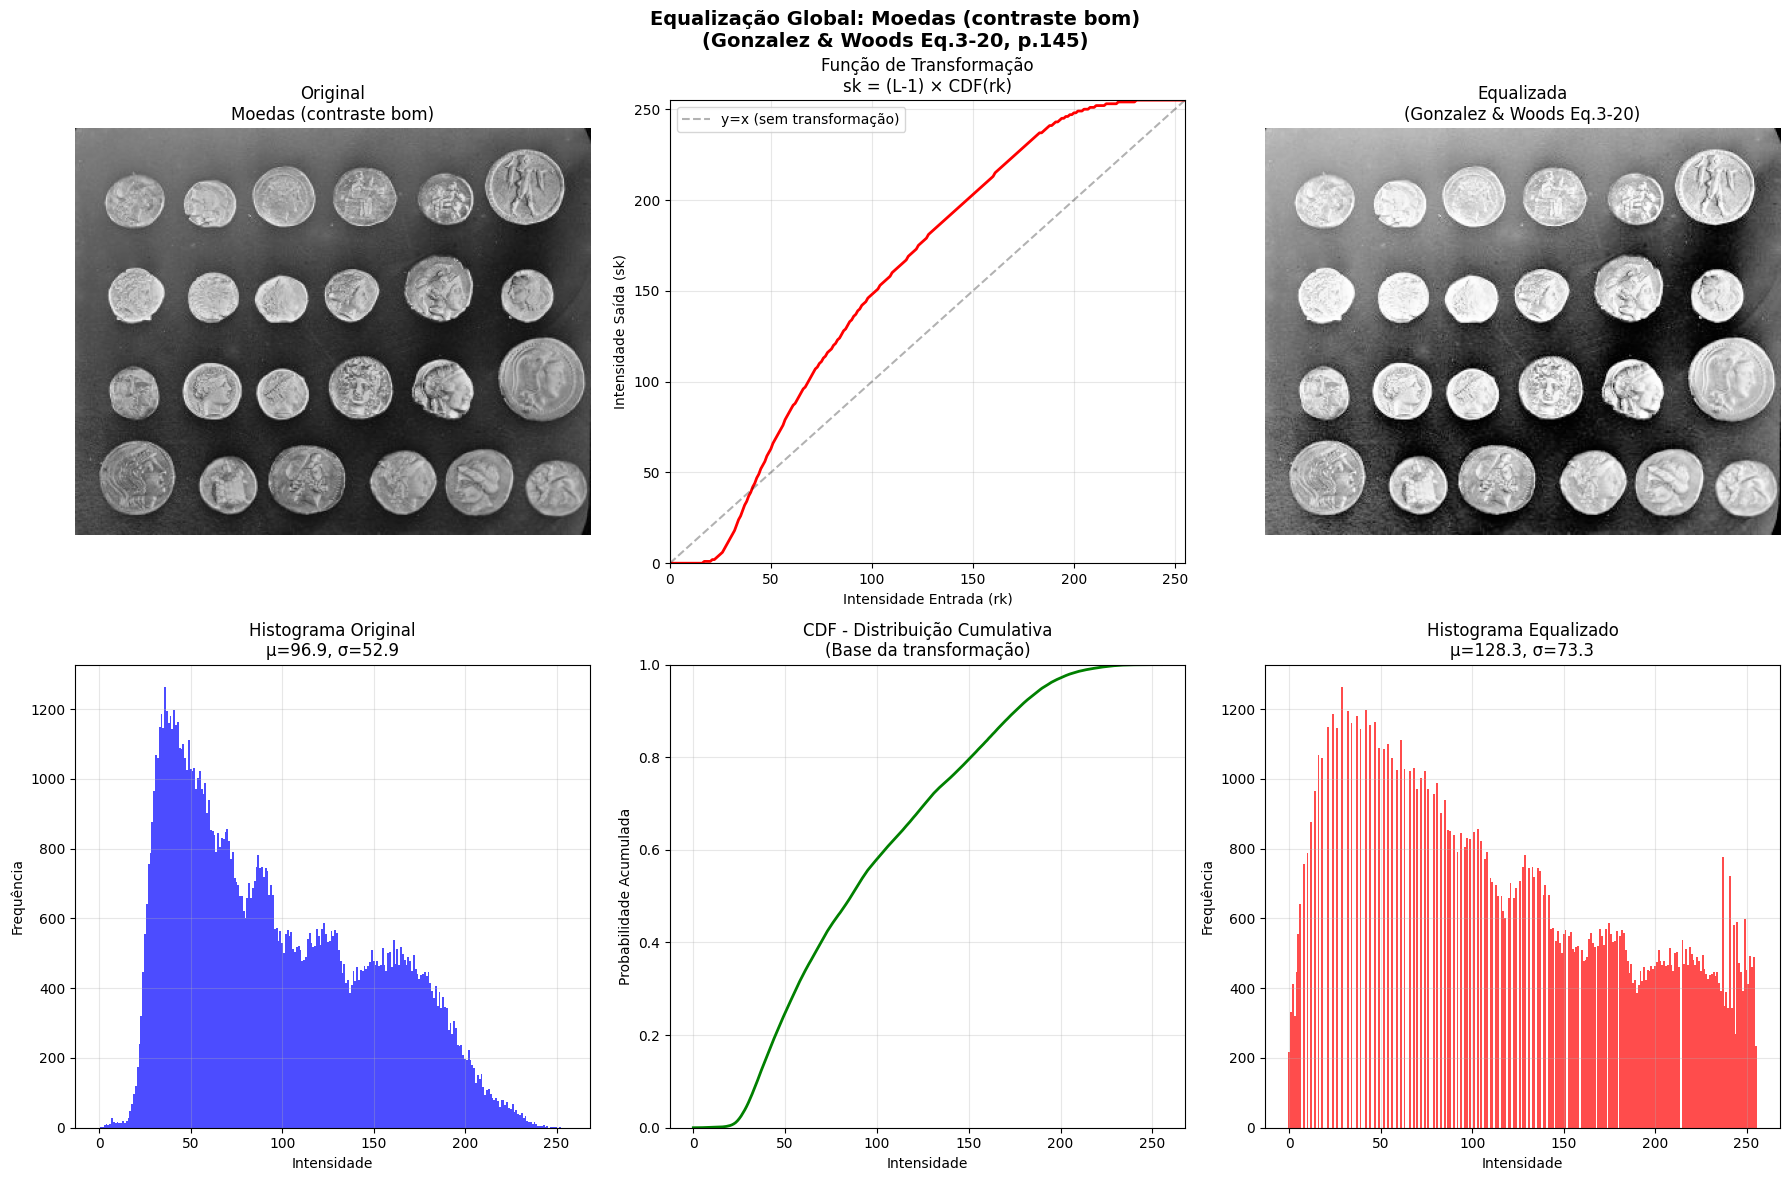

  📈 Análise de Melhoria:
     Aumento de Contraste (σ): 1.39x
     Expansão de Range: 1.02x
     Uso da faixa dinâmica: 255/255 (100.0%)

✅ Experimento de Equalização Global concluído!
💡 Observe como a função de transformação (CDF) redistribui as intensidades


In [19]:
# 🔬 EXPERIMENTO: Equalização Global de Histograma

print("📊 Equalização Global de Histograma (Gonzalez & Woods Eq.3-20)")
print("=" * 70)

# Carrega imagens com diferentes características de contraste
imagens_teste = {
    'Lua (baixo contraste)': data.moon(),
    'Câmera (contraste médio)': data.camera(),
    'Moedas (contraste bom)': data.coins()
}

for nome, img in imagens_teste.items():
    print(f"\n🖼️ Processando: {nome}")
    print("-" * 70)
    
    # Converte para escala de cinza se necessário
    if len(img.shape) == 3:
        img_cinza = processamento.rgb_para_cinza(img)
    else:
        img_cinza = img
    
    # Aplica equalização
    img_equalizada, metadados = histogramas.equalizar_histograma_global(img_cinza)
    
    # Estatísticas antes e depois
    stats_antes = histogramas.calcular_estatisticas_basicas(img_cinza)
    stats_depois = histogramas.calcular_estatisticas_basicas(img_equalizada)
    
    print(f"  📏 Estatísticas ANTES da equalização:")
    print(f"     Média: {stats_antes['media']:.1f}, Desvio Padrão: {stats_antes['desvio_padrao']:.1f}")
    print(f"     Range: [{stats_antes['minimo']:.0f}, {stats_antes['maximo']:.0f}]")
    
    print(f"  📏 Estatísticas DEPOIS da equalização:")
    print(f"     Média: {stats_depois['media']:.1f}, Desvio Padrão: {stats_depois['desvio_padrao']:.1f}")
    print(f"     Range: [{stats_depois['minimo']:.0f}, {stats_depois['maximo']:.0f}]")
    
    # Visualização comparativa
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Linha 1: Imagens
    axes[0, 0].imshow(img_cinza, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title(f"Original\n{nome}")
    axes[0, 0].axis('off')
    
    axes[0, 1].plot(metadados['funcao_transformacao'], 'r-', linewidth=2)
    axes[0, 1].set_title("Função de Transformação\nsk = (L-1) × CDF(rk)")
    axes[0, 1].set_xlabel("Intensidade Entrada (rk)")
    axes[0, 1].set_ylabel("Intensidade Saída (sk)")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim([0, 255])
    axes[0, 1].set_ylim([0, 255])
    # Adiciona linha de referência y=x
    axes[0, 1].plot([0, 255], [0, 255], 'k--', alpha=0.3, label='y=x (sem transformação)')
    axes[0, 1].legend()
    
    axes[0, 2].imshow(img_equalizada, cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title(f"Equalizada\n(Gonzalez & Woods Eq.3-20)")
    axes[0, 2].axis('off')
    
    # Linha 2: Histogramas
    axes[1, 0].bar(range(256), metadados['histograma_original'], alpha=0.7, color='blue', width=1)
    axes[1, 0].set_title(f"Histograma Original\nμ={stats_antes['media']:.1f}, σ={stats_antes['desvio_padrao']:.1f}")
    axes[1, 0].set_xlabel("Intensidade")
    axes[1, 0].set_ylabel("Frequência")
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(metadados['cdf_original'], 'g-', linewidth=2)
    axes[1, 1].set_title("CDF - Distribuição Cumulativa\n(Base da transformação)")
    axes[1, 1].set_xlabel("Intensidade")
    axes[1, 1].set_ylabel("Probabilidade Acumulada")
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim([0, 1])
    
    axes[1, 2].bar(range(256), metadados['histograma_equalizado'], alpha=0.7, color='red', width=1)
    axes[1, 2].set_title(f"Histograma Equalizado\nμ={stats_depois['media']:.1f}, σ={stats_depois['desvio_padrao']:.1f}")
    axes[1, 2].set_xlabel("Intensidade")
    axes[1, 2].set_ylabel("Frequência")
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(f"Equalização Global: {nome}\n(Gonzalez & Woods Eq.3-20, p.145)", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Análise quantitativa
    melhoria_contraste = stats_depois['desvio_padrao'] / stats_antes['desvio_padrao']
    melhoria_range = (stats_depois['amplitude'] / stats_antes['amplitude']) if stats_antes['amplitude'] > 0 else 1
    
    print(f"  📈 Análise de Melhoria:")
    print(f"     Aumento de Contraste (σ): {melhoria_contraste:.2f}x")
    print(f"     Expansão de Range: {melhoria_range:.2f}x")
    print(f"     Uso da faixa dinâmica: {stats_depois['amplitude']:.0f}/255 ({stats_depois['amplitude']/255*100:.1f}%)")

print("\n✅ Experimento de Equalização Global concluído!")
print("💡 Observe como a função de transformação (CDF) redistribui as intensidades")

### 🔍 **Análise dos Resultados:**

#### **O que observamos:**

1. **Função de Transformação (CDF):**
   - É uma função **monotônica crescente** (nunca decresce)
   - Mapeia intensidades de entrada [0,255] para saída [0,255]
   - Formato da curva revela características da imagem:
     - Curva íngreme: região com muitos pixels → espalhados na saída
     - Curva plana: região com poucos pixels → comprimidos na saída

2. **Histograma Equalizado:**
   - Tende a ser mais **uniforme** (distribuído)
   - Ocupa uma **faixa maior** da escala [0,255]
   - Pode ter **"gaps"** (bins vazios) devido à discretização

3. **Melhoria de Contraste:**
   - Desvio padrão (σ) geralmente **aumenta**
   - Amplitude usa mais da faixa dinâmica disponível
   - Detalhes em regiões escuras/claras ficam mais visíveis

#### **Quando funciona bem (Gonzalez & Woods p.138):**
- Imagens com **baixo contraste** (histograma concentrado)
- Imagens **subexpostas** ou **superexpostas**
- Quando objetivo é **melhoramento automático**

#### **Quando NÃO funciona bem (Gonzalez & Woods p.148):**
- Imagens **já bem balanceadas** → sobre-equalização
- Imagens com **muito ruído** → ruído amplificado
- Quando **brilho médio** precisa ser preservado

---

📊 CLAHE - Contrast Limited Adaptive Histogram Equalization
📚 Referência: Szeliski Eq.3.10, p.118 + Pizer et al. 1987

🖼️ Comparando: Equalização Global vs CLAHE
----------------------------------------------------------------------


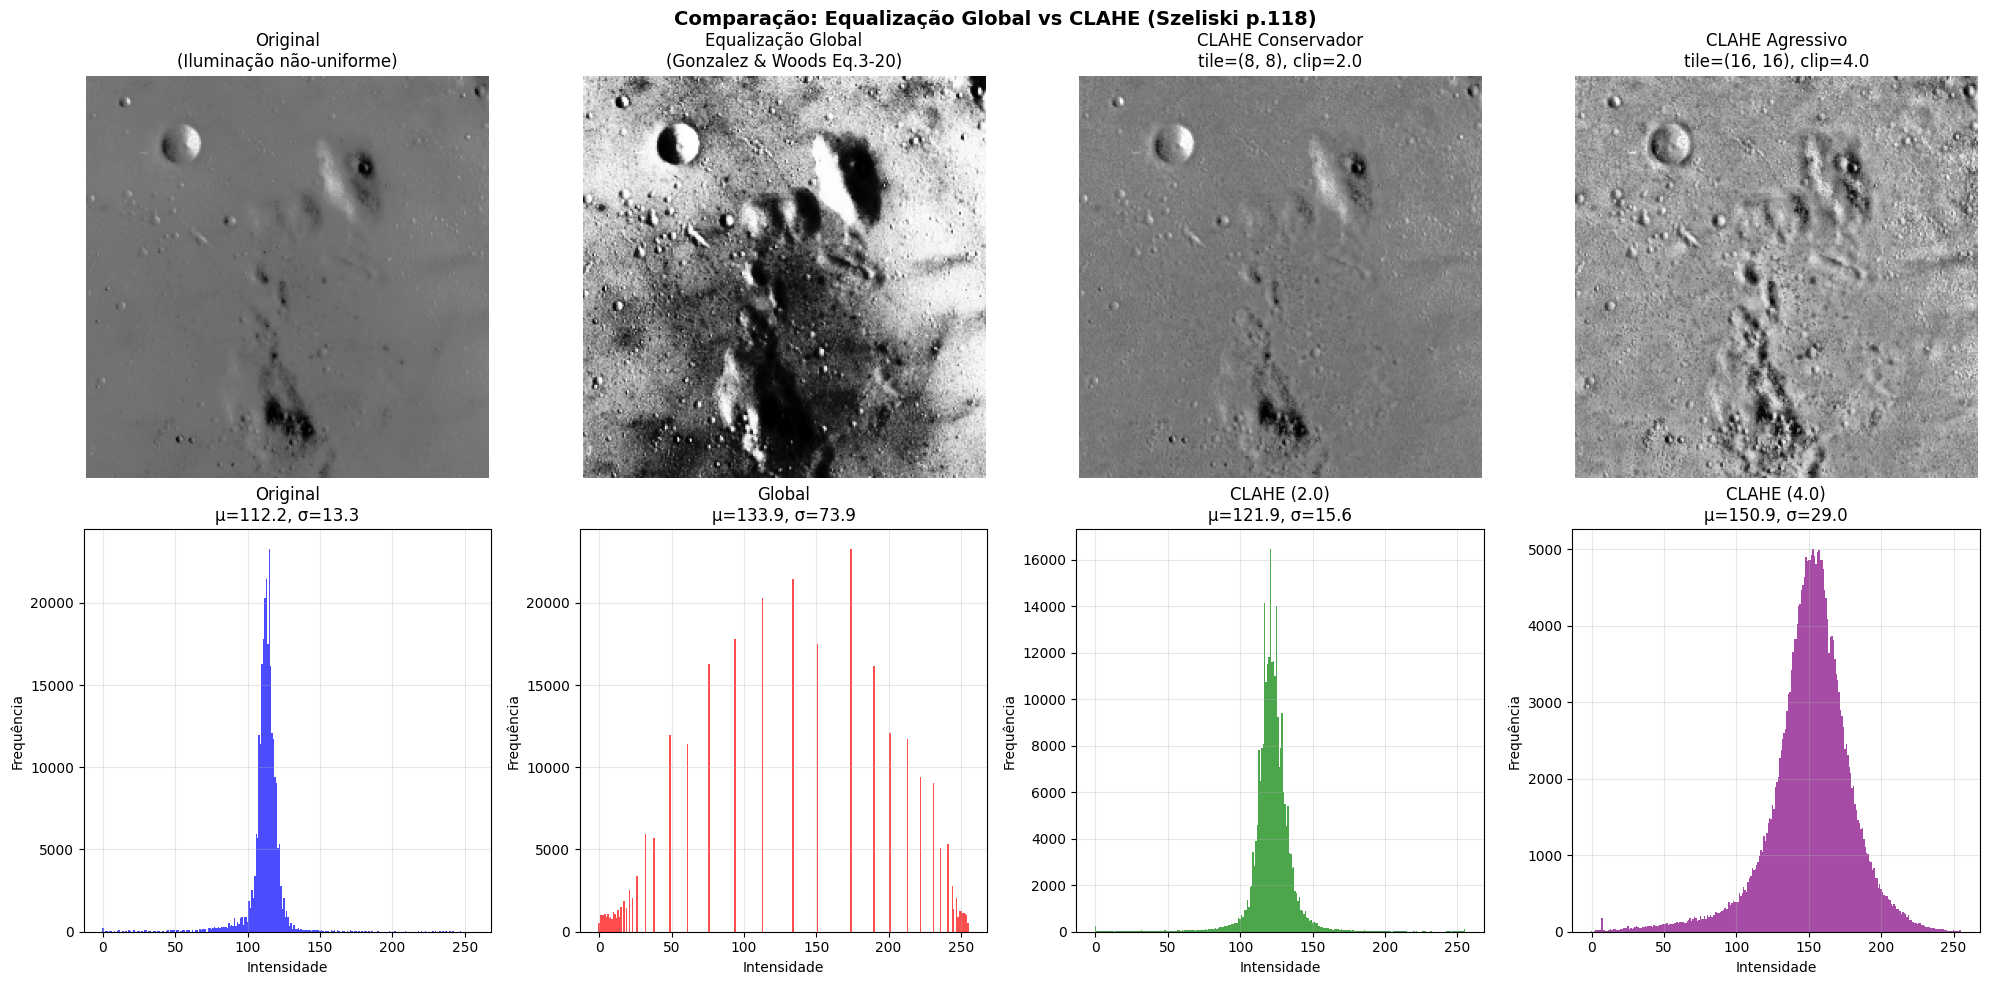


📊 Análise Comparativa:

Original:
  Média: 112.2, Desvio Padrão: 13.3
  Range: [0, 255], Amplitude: 255
  Entropia: 4.88 bits

Global:
  Média: 133.9, Desvio Padrão: 73.9
  Range: [0, 255], Amplitude: 255
  Entropia: 4.72 bits

CLAHE (2.0):
  Média: 121.9, Desvio Padrão: 15.6
  Range: [0, 255], Amplitude: 255
  Entropia: 5.49 bits

CLAHE (4.0):
  Média: 150.9, Desvio Padrão: 29.0
  Range: [0, 255], Amplitude: 255
  Entropia: 6.78 bits

💡 Observações Importantes (Szeliski p.118, Pizer et al. 1987):
• CLAHE preserva melhor os detalhes locais
• Equalização global pode produzir aparência 'lavada' (washed-out)
• Tile menor = mais adaptativo, mas pode criar artefatos
• Clip limit maior = mais contraste, mas amplifica ruído
• Interpolação bilinear (Eq.3.10) suaviza transições entre tiles

✅ Experimento CLAHE concluído!


In [20]:
# 🔬 EXPERIMENTO: CLAHE - Equalização Adaptativa com Limitação de Contraste

print("📊 CLAHE - Contrast Limited Adaptive Histogram Equalization")
print("📚 Referência: Szeliski Eq.3.10, p.118 + Pizer et al. 1987")
print("=" * 70)

# Usa imagem com iluminação não-uniforme
img_teste = data.moon()  # Lua tem regiões muito escuras e muito claras

print(f"\n🖼️ Comparando: Equalização Global vs CLAHE")
print("-" * 70)

# Aplica diferentes técnicas
img_equalizada_global, meta_global = histogramas.equalizar_histograma_global(img_teste)

# CLAHE com diferentes parâmetros
img_clahe_conservador, meta_clahe1 = histogramas.equalizar_histograma_adaptativa(
    img_teste, 
    tamanho_tile=(8, 8),
    limite_contraste=2.0
)

img_clahe_agressivo, meta_clahe2 = histogramas.equalizar_histograma_adaptativa(
    img_teste,
    tamanho_tile=(16, 16),
    limite_contraste=4.0
)

# Visualização comparativa
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Linha 1: Imagens
axes[0, 0].imshow(img_teste, cmap='gray')
axes[0, 0].set_title("Original\n(Iluminação não-uniforme)")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_equalizada_global, cmap='gray')
axes[0, 1].set_title("Equalização Global\n(Gonzalez & Woods Eq.3-20)")
axes[0, 1].axis('off')

axes[0, 2].imshow(img_clahe_conservador, cmap='gray')
axes[0, 2].set_title(f"CLAHE Conservador\ntile={meta_clahe1['tamanho_tile']}, clip={meta_clahe1['limite_contraste']}")
axes[0, 2].axis('off')

axes[0, 3].imshow(img_clahe_agressivo, cmap='gray')
axes[0, 3].set_title(f"CLAHE Agressivo\ntile={meta_clahe2['tamanho_tile']}, clip={meta_clahe2['limite_contraste']}")
axes[0, 3].axis('off')

# Linha 2: Histogramas
imagens_dict = {
    'Original': img_teste,
    'Global': img_equalizada_global,
    'CLAHE (2.0)': img_clahe_conservador,
    'CLAHE (4.0)': img_clahe_agressivo
}

cores = ['blue', 'red', 'green', 'purple']
for idx, (nome, img) in enumerate(imagens_dict.items()):
    hist = histogramas.calcular_histograma(img)
    stats = histogramas.calcular_estatisticas_basicas(img)
    
    axes[1, idx].bar(range(256), hist, alpha=0.7, color=cores[idx], width=1)
    axes[1, idx].set_title(f"{nome}\nμ={stats['media']:.1f}, σ={stats['desvio_padrao']:.1f}")
    axes[1, idx].set_xlabel("Intensidade")
    axes[1, idx].set_ylabel("Frequência")
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle("Comparação: Equalização Global vs CLAHE (Szeliski p.118)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Análise quantitativa
print("\n📊 Análise Comparativa:")
print("=" * 70)

for nome, img in imagens_dict.items():
    stats = histogramas.calcular_estatisticas_basicas(img)
    entropia = histogramas.calcular_entropia(img)
    
    print(f"\n{nome}:")
    print(f"  Média: {stats['media']:.1f}, Desvio Padrão: {stats['desvio_padrao']:.1f}")
    print(f"  Range: [{stats['minimo']:.0f}, {stats['maximo']:.0f}], Amplitude: {stats['amplitude']:.0f}")
    print(f"  Entropia: {entropia:.2f} bits")

print("\n💡 Observações Importantes (Szeliski p.118, Pizer et al. 1987):")
print("• CLAHE preserva melhor os detalhes locais")
print("• Equalização global pode produzir aparência 'lavada' (washed-out)")
print("• Tile menor = mais adaptativo, mas pode criar artefatos")
print("• Clip limit maior = mais contraste, mas amplifica ruído")
print("• Interpolação bilinear (Eq.3.10) suaviza transições entre tiles")

print("\n✅ Experimento CLAHE concluído!")

## 🎓 Resumo: Equalização de Histogramas

### ✅ **O que Aprendemos:**

#### 📊 **1. Equalização Global (Gonzalez & Woods Eq.3-20)**
- **Fórmula**: sk = (L-1) × Σ(j=0 to k) pr(rj)
- **Ideia**: Usar CDF como função de transformação
- **Objetivo**: Distribuição uniforme de intensidades
- **Resultado**: Histograma mais espalhado, contraste melhorado
- **Implementação**: ~10 linhas de código (CDF + lookup table)

#### 🎨 **2. CLAHE (Szeliski Eq.3.10, Pizer et al. 1987)**
- **Diferença principal**: Equalização **local** por tiles
- **Limitação de contraste**: Previne amplificação excessiva
- **Interpolação bilinear**: Suaviza transições entre blocos
- **Vantagem**: Preserva detalhes locais, evita sobre-equalização
- **Parâmetros típicos**: tiles 8×8 a 64×64, clip limit 2.0-4.0

#### 📐 **3. Histogram Specification (Gonzalez & Woods Eq.3-21 a 3-23)**
- **Objetivo**: Transformar para histograma **específico** (não apenas uniforme)
- **Algoritmo**: Equalizar entrada → mapear para CDF alvo invertido
- **Aplicações**: Style transfer, normalização, efeitos artísticos

---

### 📚 **Fundamentação Acadêmica Completa:**

| **Técnica** | **Referência Principal** | **Equação** | **Complexidade** | **Melhor Uso** |
|-------------|--------------------------|-------------|------------------|----------------|
| **Equalização Global** | G&W Eq.3-20, p.145 | sk = (L-1)×CDF(rk) | O(N) | Baixo contraste uniforme |
| **CLAHE** | Szeliski Eq.3.10, p.118 | Interpolação bilinear | O(N×M²) | Iluminação não-uniforme |
| **Specification** | G&W Eq.3-21 to 3-23 | zq = G⁻¹(sk) | O(N) | Matching com referência |

---

### 🎯 **Guia de Aplicação Prática:**

| **Cenário** | **Técnica Recomendada** | **Parâmetros** | **Resultado Esperado** |
|-------------|-------------------------|----------------|------------------------|
| **Imagem subexposta** | Equalização Global | Padrão | Contraste melhorado |
| **Iluminação variável** | CLAHE | tile=8×8, clip=2.0 | Detalhes em todas regiões |
| **Imagens médicas** | CLAHE | tile=16×16, clip=3.0 | Estruturas anatômicas visíveis |
| **Fotografia noturna** | CLAHE | tile=32×32, clip=4.0 | Detalhes em sombras |
| **Normalização dataset** | Specification | Histograma gaussiano | Aparência consistente |

---

### ⚠️ **Limitações e Cuidados:**

#### **Equalização Global:**
- ❌ Sobre-equalização em imagens já balanceadas
- ❌ Amplifica ruído uniformemente
- ❌ Não preserva brilho médio original
- ✅ Rápida, simples, completamente automática

#### **CLAHE:**
- ❌ Mais lenta computacionalmente (O(N×M²))
- ❌ Requer ajuste de parâmetros (tile size, clip limit)
- ❌ Pode criar artefatos com tiles muito pequenos
- ✅ Melhor para iluminação não-uniforme
- ✅ Controle fino sobre amplificação

---

### 🧮 **Implementações Desenvolvidas:**

✅ **Módulo `cv_lib/analise/histogramas.py`:**
- `equalizar_histograma_global()` - Implementação manual educacional
- `equalizar_histograma_adaptativa()` - CLAHE usando skimage
- `especificar_histograma()` - Histogram matching completo
- Todas funções com documentação acadêmica completa

✅ **Validação:**
- Comparação visual antes/depois
- Análise quantitativa (μ, σ, amplitude)
- Visualização da função de transformação (CDF)
- Comparação entre técnicas

---

### 💡 **Conclusões Principais:**

1. **Equalização de histogramas é fundamental** para melhoramento automático de contraste
2. **CDF como função de transformação** é a base matemática da técnica
3. **CLAHE supera equalização global** em imagens com iluminação não-uniforme
4. **Limitação de contraste** é essencial para evitar amplificação de ruído
5. **Interpolação bilinear** previne artefatos de bloco no CLAHE
6. **Não é solução universal**: analisar características da imagem primeiro

---

*📊 **Seção de Equalização de Histogramas concluída com rigor acadêmico!** Você agora domina técnicas de melhoramento de contraste baseadas em histograma, com implementações validadas e fundamentação teórica completa.* 🚀